# Quantifying Mtb on a single-cell level across large tissue slices

First work on a single example to determine thresholds then iterate over all slices.

In [7]:
import os
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm

# Load final results

In [74]:
df = pd.read_parquet('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/mtb_tissue_quantification.parquet')

In [75]:
df

,zarr_address,mouse_num,rep_id,split,host_id,host_area,host_eccentricity,is_infected,mtb_count,total_mtb_area,...,centroid_x,bbox_minr,bbox_minc,bbox_maxr,bbox_maxc,granuloma_region,exclusion_region,timer_ratio,condition,mouse_id
0,rep_1_mouse_1_max_proj.zarr,1,1,None,1,4578.0,0.640359,False,0,0.0,...,6753.588467,4774,6715,4850,6798,False,False,NaN,H2O,1
1,rep_1_mouse_1_max_proj.zarr,1,1,None,2,11804.0,0.860311,False,0,0.0,...,6659.255083,6057,6617,6220,6708,False,False,NaN,H2O,1
2,rep_1_mouse_1_max_proj.zarr,1,1,None,3,20160.0,0.811023,False,0,0.0,...,11423.436905,79,11322,196,11528,False,False,NaN,H2O,1
3,rep_1_mouse_1_max_proj.zarr,1,1,None,4,15536.0,0.801217,False,0,0.0,...,9340.931321,88,9252,193,9430,False,False,NaN,H2O,1
4,rep_1_mouse_1_max_proj.zarr,1,1,None,5,3999.0,0.702588,False,0,0.0,...,8804.503626,91,8764,156,8842,False,False,NaN,H2O,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5738151,rep_2_mouse_16_top_max_proj.zarr,16,2,top,102459,1512.0,0.902598,False,0,0.0,...,32019.970899,34302,31984,34331,32052,False,False,NaN,PZA,27
5738152,rep_2_mouse_16_top_max_proj.zarr,16,2,top,102460,2852.0,0.538824,False,0,0.0,...,32493.679523,34274,32461,34331,32538,False,False,NaN,PZA,27
5738153,rep_2_mouse_16_top_max_proj.zarr,16,2,top,102461,1572.0,0.953683,False,0,0.0,...,30435.859415,34302,30390,34331,30470,False,False,NaN,PZA,27
5738154,rep_2_mouse_16_top_max_proj.zarr,16,2,top,102462,3419.0,0.779260,False,0,0.0,...,30271.125183,34280,30233,34331,30316,False,False,NaN,PZA,27


In [143]:
df.groupby(['mouse_num', 'rep_id', 'mouse_id', 'condition'])['mtb_count'].sum().reset_index()


,mouse_num,rep_id,mouse_id,condition,mtb_count
0,1,1,1,H2O,14336
1,1,2,12,H2O,22660
2,2,1,2,DMSO,1675
3,2,2,13,H2O,3421
4,3,1,4,RIF,332
5,3,2,14,H2O,3488
6,4,1,5,RIF,379
7,4,2,15,DMSO,3146
8,5,1,6,RIF,288
9,5,2,16,DMSO,2323


In [139]:
df[['mouse_num', 'rep_id', 'mouse_id', 'condition']].drop_duplicates()

,mouse_num,rep_id,mouse_id,condition
0,1,1,1,H2O
138849,2,1,2,DMSO
294211,3,1,4,RIF
422783,4,1,5,RIF
445481,5,1,6,RIF
621337,6,1,7,RIF
857039,7,1,8,PZA
1042403,8,1,9,PZA
1240565,9,1,10,PZA
1475312,10,1,11,PZA


In [133]:
df['mtb_count'].sum()

np.int64(374848)

In [137]:
df[df['mouse_id']!=23]['mtb_count'].sum()

np.int64(82693)

# Plot

In [36]:
# number of cell detections in granuloma and false ROIs
5738156 - 5303248

434908

In [78]:
intracellular_df = df[(df['granuloma_region']==False) & (df['exclusion_region']==False)]
intracellular_df

,zarr_address,mouse_num,rep_id,split,host_id,host_area,host_eccentricity,is_infected,mtb_count,total_mtb_area,...,centroid_x,bbox_minr,bbox_minc,bbox_maxr,bbox_maxc,granuloma_region,exclusion_region,timer_ratio,condition,mouse_id
0,rep_1_mouse_1_max_proj.zarr,1,1,None,1,4578.0,0.640359,False,0,0.0,...,6753.588467,4774,6715,4850,6798,False,False,NaN,H2O,1
1,rep_1_mouse_1_max_proj.zarr,1,1,None,2,11804.0,0.860311,False,0,0.0,...,6659.255083,6057,6617,6220,6708,False,False,NaN,H2O,1
2,rep_1_mouse_1_max_proj.zarr,1,1,None,3,20160.0,0.811023,False,0,0.0,...,11423.436905,79,11322,196,11528,False,False,NaN,H2O,1
3,rep_1_mouse_1_max_proj.zarr,1,1,None,4,15536.0,0.801217,False,0,0.0,...,9340.931321,88,9252,193,9430,False,False,NaN,H2O,1
4,rep_1_mouse_1_max_proj.zarr,1,1,None,5,3999.0,0.702588,False,0,0.0,...,8804.503626,91,8764,156,8842,False,False,NaN,H2O,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5738151,rep_2_mouse_16_top_max_proj.zarr,16,2,top,102459,1512.0,0.902598,False,0,0.0,...,32019.970899,34302,31984,34331,32052,False,False,NaN,PZA,27
5738152,rep_2_mouse_16_top_max_proj.zarr,16,2,top,102460,2852.0,0.538824,False,0,0.0,...,32493.679523,34274,32461,34331,32538,False,False,NaN,PZA,27
5738153,rep_2_mouse_16_top_max_proj.zarr,16,2,top,102461,1572.0,0.953683,False,0,0.0,...,30435.859415,34302,30390,34331,30470,False,False,NaN,PZA,27
5738154,rep_2_mouse_16_top_max_proj.zarr,16,2,top,102462,3419.0,0.779260,False,0,0.0,...,30271.125183,34280,30233,34331,30316,False,False,NaN,PZA,27


In [135]:
intracellular_df['mtb_count'].sum()

np.int64(78475)

In [79]:
print()

### Percentage of infected cells

In [83]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np

/tmp/ipykernel_10732/3197385371.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


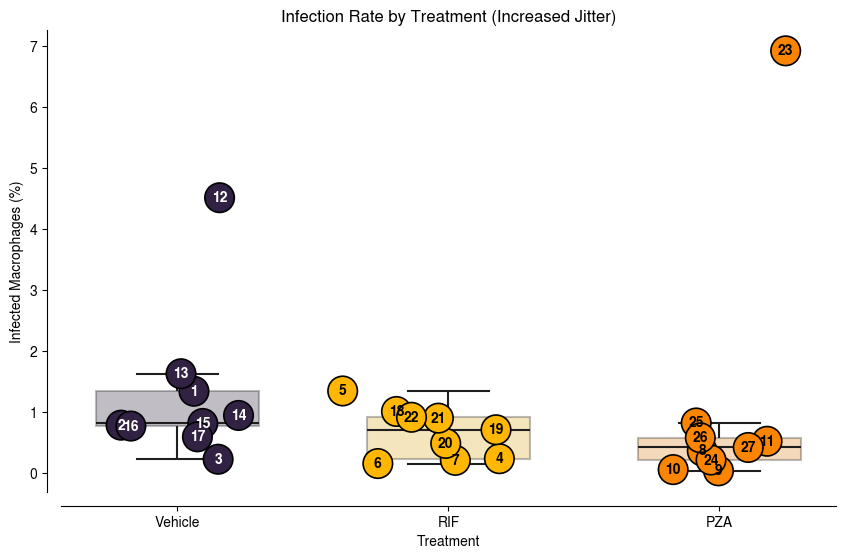

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# --- THEMES AND PARAMETERS ---
CORE_COLORS = {
    'Vehicle': '#312244', 
    'RIF':     '#ffb703', 
    'PZA':     '#fb8500'
}
ORDER = ['Vehicle', 'RIF', 'PZA']

# 1. Calculate % Infected per Mouse
perc_infected_df = (
    intracellular_df.groupby(['mouse_id', 'condition'])['is_infected']
    .mean()
    .mul(100)
    .reset_index(name='percent_infected')
)

# 2. Remap to Vehicle
perc_infected_df['plot_condition'] = perc_infected_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')

# 3. Stronger Jitter Calculation (Increased Scale)
cond_map = {cond: i for i, cond in enumerate(ORDER)}
rng = np.random.default_rng(42)
# Increased scale to 0.2 for a much wider horizontal spread
perc_infected_df['x_jitter'] = (
    perc_infected_df['plot_condition'].map(cond_map) + 
    rng.normal(loc=0, scale=0.2, size=len(perc_infected_df))
)

# Initialize Figure
f, ax = plt.subplots(figsize=(10, 6))

# 4. Box Plot
sns.boxplot(
    data=perc_infected_df,
    x='plot_condition',
    y='percent_infected',
    order=ORDER,
    ax=ax,
    palette=CORE_COLORS,
    width=0.6,        # Widened box slightly to accommodate more jitter
    fliersize=0,      
    linewidth=1.5,
    boxprops={'alpha': 0.3} 
)

# 5. Scatter Plot (Numbered circles)
sns.scatterplot(
    data=perc_infected_df,
    x='x_jitter',
    y='percent_infected',
    hue='plot_condition',
    hue_order=ORDER,
    palette=CORE_COLORS,
    marker='o',
    s=450, 
    edgecolor='black',
    linewidth=1.2,
    ax=ax,
    legend=False,
    zorder=3
)

# 6. Overlay Mouse ID Numbers
for i in range(len(perc_infected_df)):
    row = perc_infected_df.iloc[i]
    text_color = 'white' if row['plot_condition'] == 'Vehicle' else 'black'
    
    ax.text(
        x=row['x_jitter'],
        y=row['percent_infected'],
        s=str(int(row['mouse_id'])),
        fontsize=10,
        color=text_color,
        ha='center',
        va='center',
        fontweight='bold',
        zorder=4
    )

# 7. Refine Axes
ax.set_xlabel('Treatment')
ax.set_ylabel('Infected Macrophages (%)')
ax.set_title('Infection Rate by Treatment (Increased Jitter)')

sns.despine(offset=10)
ax.set_facecolor('white')

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/Percent_Infected_Boxplot_Wide_Jitter.pdf', bbox_inches='tight', dpi=314)
plt.show()

/tmp/ipykernel_10732/987060007.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


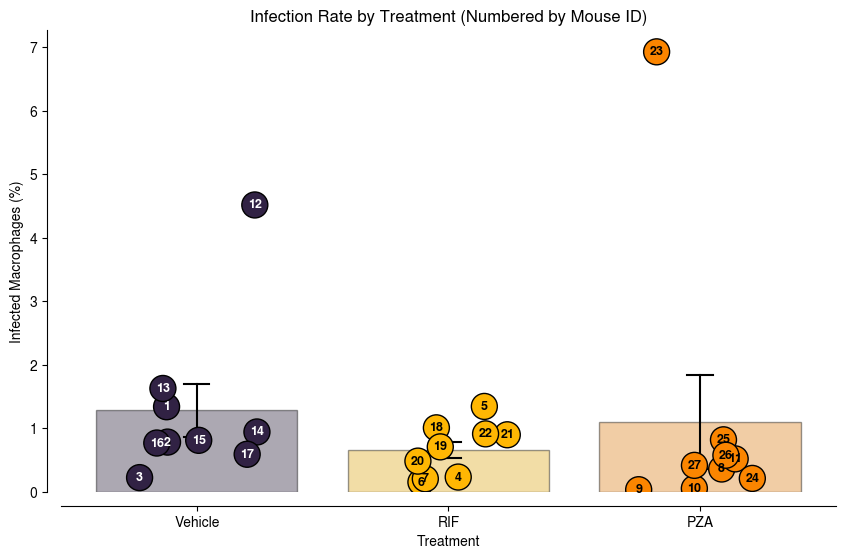

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# --- THEMES AND PARAMETERS ---
# Change these three hex codes to update the entire plot's color scheme
CORE_COLORS = {
    'Vehicle': '#312244', 
    'RIF':     '#ffb703', 
    'PZA':     '#fb8500'
}
ORDER = ['Vehicle', 'RIF', 'PZA']

# 1. Calculate % Infected per Mouse
perc_infected_df = (
    intracellular_df.groupby(['mouse_id', 'condition'])['is_infected']
    .mean()
    .mul(100)
    .reset_index(name='percent_infected')
)

# 2. Remap to Vehicle
perc_infected_df['plot_condition'] = perc_infected_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')

# 3. Jitter Calculation
cond_map = {cond: i for i, cond in enumerate(ORDER)}
jitter_strength = 0.25
rng = np.random.default_rng()
perc_infected_df['x_jitter'] = perc_infected_df['plot_condition'].map(cond_map) + rng.uniform(-jitter_strength, jitter_strength, size=len(perc_infected_df))

# Initialize Figure
f, ax = plt.subplots(figsize=(10, 6))

# 4. Bar Plot
sns.barplot(
    data=perc_infected_df,
    x='plot_condition',
    y='percent_infected',
    order=ORDER,
    ax=ax,
    palette=CORE_COLORS,
    errorbar=('ci', 68),
    capsize=0.1,
    alpha=0.4,
    err_kws={'color': 'black', 'linewidth': 1.5},
    edgecolor='black',
    linewidth=1,
    legend=False
)

# 5. Scatter Plot (Container circles)
sns.scatterplot(
    data=perc_infected_df,
    x='x_jitter',
    y='percent_infected',
    hue='plot_condition',
    hue_order=ORDER,
    palette=CORE_COLORS,
    marker='o',
    s=350, 
    edgecolor='black',
    linewidth=1,
    ax=ax,
    legend=False,
    zorder=3
)

# 6. Overlay Mouse ID Numbers with Contrast Logic
for i in range(len(perc_infected_df)):
    row = perc_infected_df.iloc[i]
    
    # Simple logic: use white text for Vehicle/PZA, black for RIF
    # If you change CORE_COLORS, you can adjust this conditional.
    text_color = 'white' if row['plot_condition'] in ['Vehicle'] else 'black'
    
    ax.text(
        x=row['x_jitter'],
        y=row['percent_infected'],
        s=str(int(row['mouse_id'])),
        fontsize=9,
        color=text_color,
        ha='center',
        va='center',
        fontweight='bold',
        zorder=4
    )

# 7. Refine Axes
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels(ORDER)
ax.set_xlabel('Treatment')
ax.set_ylabel('Infected Macrophages (%)')
ax.set_title('Infection Rate by Treatment (Numbered by Mouse ID)')

sns.despine(offset=10)
ax.set_facecolor('white')

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/Percent_Infected_Numbered.pdf', bbox_inches='tight', dpi=314)
plt.show()

/tmp/ipykernel_10732/401491961.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


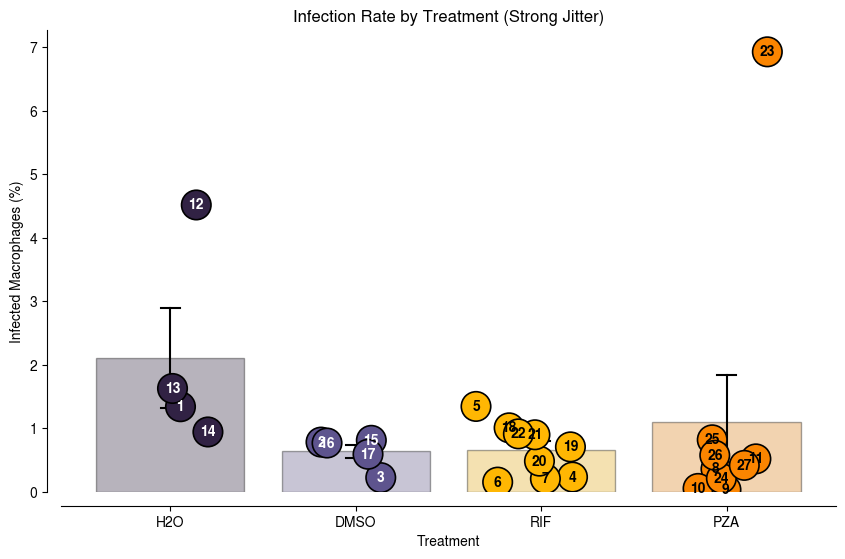

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# 1. Define Expanded Palette and Order
CORE_COLORS = {
    'H2O':  '#312244', # Deep Midnight
    'DMSO': '#5e548e', # Muted Indigo
    'RIF':  '#ffb703', # Bright Yellow
    'PZA':  '#fb8500'  # Vivid Orange
}
order = ['H2O', 'DMSO', 'RIF', 'PZA']

# 2. Calculate % Infected per Mouse
perc_infected_df = (
    intracellular_df.groupby(['mouse_id', 'condition'])['is_infected']
    .mean()
    .mul(100)
    .reset_index(name='percent_infected')
)

# 3. Enhanced Jitter Calculation (Normal Distribution)
# Increased scale to 0.18 and switched to a normal distribution 
# to ensure points spread more widely across the bar width.
cond_map = {cond: i for i, cond in enumerate(order)}
rng = np.random.default_rng(42) # Seeded for consistent positioning
perc_infected_df['x_jitter'] = (
    perc_infected_df['condition'].map(cond_map) + 
    rng.normal(loc=0, scale=0.18, size=len(perc_infected_df))
)

# Initialize Figure
f, ax = plt.subplots(figsize=(10, 6))

# 4. Bar Plot
sns.barplot(
    data=perc_infected_df,
    x='condition',
    y='percent_infected',
    order=order,
    ax=ax,
    palette=CORE_COLORS,
    errorbar=('ci', 68),
    capsize=0.1,
    alpha=0.35, # Lighter bars help the numbered circles stand out
    err_kws={'color': 'black', 'linewidth': 1.5},
    edgecolor='black',
    linewidth=1,
    legend=False
)

# 5. Scatter Plot (Container circles)
sns.scatterplot(
    data=perc_infected_df,
    x='x_jitter',
    y='percent_infected',
    hue='condition',
    hue_order=order,
    palette=CORE_COLORS,
    marker='o',
    s=450, # Slightly larger container for better number legibility
    edgecolor='black',
    linewidth=1.2,
    ax=ax,
    legend=False,
    zorder=3
)

# 6. Overlay Mouse ID Numbers with Contrast Logic
for i in range(len(perc_infected_df)):
    row = perc_infected_df.iloc[i]
    
    # Contrast logic for Midnight & Orchid palette
    text_color = 'white' if row['condition'] in ['H2O', 'DMSO'] else 'black'
    
    ax.text(
        x=row['x_jitter'],
        y=row['percent_infected'],
        s=str(int(row['mouse_id'])),
        fontsize=10,
        color=text_color,
        ha='center',
        va='center',
        fontweight='bold',
        zorder=4
    )

# 7. Refine Axes
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_xlabel('Treatment')
ax.set_ylabel('Infected Macrophages (%)')
ax.set_title('Infection Rate by Treatment (Strong Jitter)')

sns.despine(offset=10)
ax.set_facecolor('white')

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/Percent_Infected_Strong_Jitter.pdf', bbox_inches='tight', dpi=314)
plt.show()

# Timer ratio

### per cell

In [86]:
df.keys()

Index(['zarr_address', 'mouse_num', 'rep_id', 'split', 'host_id', 'host_area',
       'host_eccentricity', 'is_infected', 'mtb_count', 'total_mtb_area',
       'mean_mtb_ch1', 'mean_mtb_ch2', 'centroid_y', 'centroid_x', 'bbox_minr',
       'bbox_minc', 'bbox_maxr', 'bbox_maxc', 'granuloma_region',
       'exclusion_region', 'timer_ratio', 'condition', 'mouse_id'],
      dtype='object')

/tmp/ipykernel_10732/3104273153.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


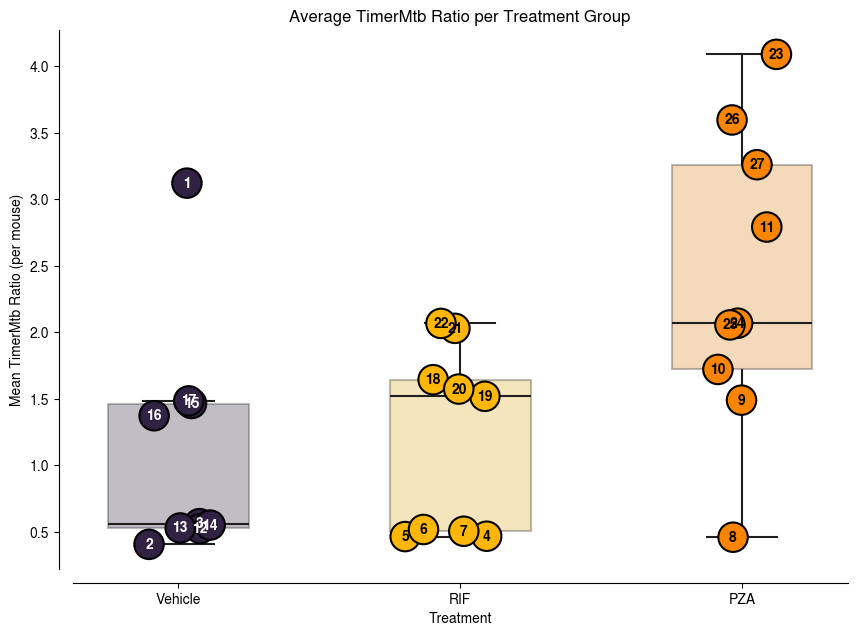

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# --- THEME CONFIGURATION ---
CORE_COLORS = {
    'Vehicle': '#312244', 
    'RIF':     '#ffb703', 
    'PZA':     '#fb8500'  
}
ORDER = ['Vehicle', 'RIF', 'PZA']

# 1. Prepare Data
mouse_means = (
    intracellular_df.groupby(['mouse_id', 'condition'])['timer_ratio']
    .mean()
    .reset_index()
)

# Remap to 'Vehicle'
mouse_means['plot_condition'] = mouse_means['condition'].replace(['H2O', 'DMSO'], 'Vehicle')

# 2. Strong Jitter Calculation
cond_map = {cond: i for i, cond in enumerate(ORDER)}
jitter_strength = 0.2
rng = np.random.default_rng(42)
mouse_means['x_jitter'] = mouse_means['plot_condition'].map(cond_map) + rng.normal(0, 0.1, size=len(mouse_means))

# 3. Initialize Figure
f, ax = plt.subplots(figsize=(10, 7))

# 4. Box Plot (Mouse-level average distribution)
sns.boxplot(
    data=mouse_means,
    x='plot_condition',
    y='timer_ratio',
    order=ORDER,
    palette=CORE_COLORS,
    width=0.5,
    fliersize=0,      # Hide outliers since we plot all points individually
    linewidth=1.5,
    boxprops={'alpha': 0.3}, # Lightened boxes
    ax=ax
)

# 5. Scatter Plot (Mouse-level means as numbered circles)
sns.scatterplot(
    data=mouse_means,
    x='x_jitter',
    y='timer_ratio',
    hue='plot_condition',
    hue_order=ORDER,
    palette=CORE_COLORS,
    marker='o',
    s=450,
    edgecolor='black',
    linewidth=1.5,
    ax=ax,
    legend=False,
    zorder=3 
)

# 6. Overlay Mouse ID Numbers
for i in range(len(mouse_means)):
    row = mouse_means.iloc[i]
    text_color = 'white' if row['plot_condition'] == 'Vehicle' else 'black'
    
    ax.text(
        x=row['x_jitter'],
        y=row['timer_ratio'],
        s=str(int(row['mouse_id'])),
        fontsize=10,
        color=text_color,
        ha='center',
        va='center',
        fontweight='bold',
        zorder=4
    )

# 7. Refine Axes
ax.set_xlabel('Treatment')
ax.set_ylabel('Mean TimerMtb Ratio (per mouse)')
ax.set_title('Average TimerMtb Ratio per Treatment Group')

sns.despine(offset=10)
ax.set_facecolor('white')

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/timer_ratio_boxplot_numbered.pdf', bbox_inches='tight', dpi=314)
plt.show()

/tmp/ipykernel_10732/622923075.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


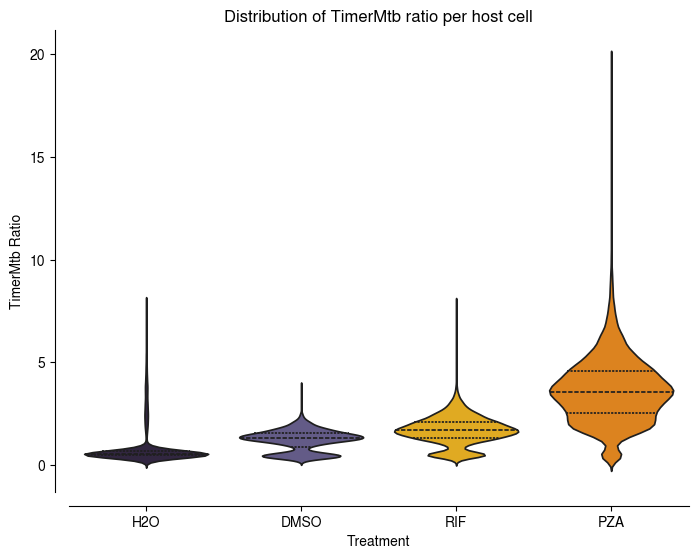

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# 1. Define Expanded Palette
# Using two shades of purple/indigo for controls to distinguish them from treatments
CORE_COLORS = {
    'H2O':  '#312244', # Deep Midnight
    'DMSO': '#5e548e', # Muted Indigo
    'RIF':  '#ffb703', # Bright Yellow
    'PZA':  '#fb8500'  # Vivid Orange
}
condition_order = ['H2O', 'DMSO', 'RIF', 'PZA']

# 2. Plot
f, ax = plt.subplots(figsize=(8, 6))

sns.violinplot(
    data=intracellular_df, 
    x='condition', 
    y='timer_ratio', 
    order=condition_order,
    palette=CORE_COLORS, 
    width=0.8, 
    inner='quart',
    ax=ax
)

# 3. Final Formatting
sns.despine(offset=10)
ax.set_title('Distribution of TimerMtb ratio per host cell')
ax.set_xlabel('Treatment')
ax.set_ylabel('TimerMtb Ratio')

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/timer_ratio_per_cell_separated_orchid.pdf', bbox_inches='tight', dpi=314)
plt.show()

/tmp/ipykernel_10732/4117666646.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intracellular_df['plot_condition'] = intracellular_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')
/tmp/ipykernel_10732/4117666646.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


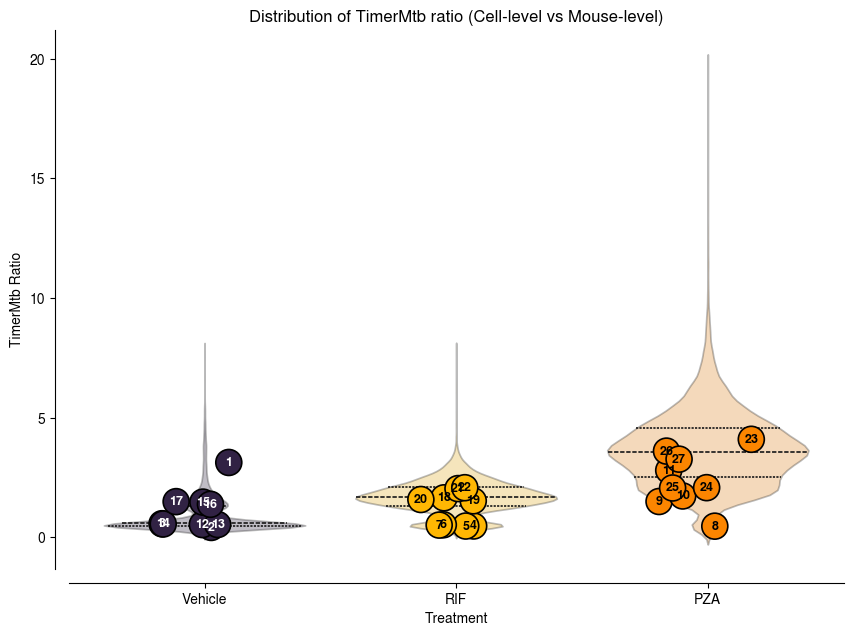

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# --- THEME CONFIGURATION ---
# Midnight & Orchid Palette
CORE_COLORS = {
    'Vehicle': '#312244', # Deep Midnight Purple
    'RIF':     '#ffb703', # Bright Yellow
    'PZA':     '#fb8500'  # Vivid Orange
}
ORDER = ['Vehicle', 'RIF', 'PZA']

# 1. Prepare Data
mouse_means = (
    intracellular_df.groupby(['mouse_id', 'condition'])['timer_ratio']
    .mean()
    .reset_index()
)

# Remap to 'Vehicle'
intracellular_df['plot_condition'] = intracellular_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')
mouse_means['plot_condition'] = mouse_means['condition'].replace(['H2O', 'DMSO'], 'Vehicle')

# 2. Jitter Calculation
cond_map = {cond: i for i, cond in enumerate(ORDER)}
jitter_strength = 0.2
rng = np.random.default_rng()
mouse_means['x_jitter'] = mouse_means['plot_condition'].map(cond_map) + rng.uniform(-jitter_strength, jitter_strength, size=len(mouse_means))

# 3. Initialize Figure
f, ax = plt.subplots(figsize=(10, 7))

# 4. Violin Plot (Cell-level distribution)
sns.violinplot(
    data=intracellular_df,
    x='plot_condition',
    y='timer_ratio',
    order=ORDER,
    palette=CORE_COLORS,
    width=0.8,
    inner='quart',
    alpha=0.3, 
    ax=ax
)

# 5. Scatter Plot (Mouse-level means as numbered circles)
sns.scatterplot(
    data=mouse_means,
    x='x_jitter',
    y='timer_ratio',
    hue='plot_condition',
    hue_order=ORDER,
    palette=CORE_COLORS,
    marker='o',
    s=350,
    edgecolor='black',
    linewidth=1.2,
    ax=ax,
    legend=False,
    zorder=3 
)

# 6. Overlay Mouse ID Numbers
for i in range(len(mouse_means)):
    row = mouse_means.iloc[i]
    
    # Contrast logic for Midnight & Orchid: 
    # Vehicle (Dark Purple) needs white text. 
    # RIF (Yellow) and PZA (Orange) need black text.
    text_color = 'white' if row['plot_condition'] == 'Vehicle' else 'black'
    
    ax.text(
        x=row['x_jitter'],
        y=row['timer_ratio'],
        s=str(int(row['mouse_id'])),
        fontsize=9,
        color=text_color,
        ha='center',
        va='center',
        fontweight='bold',
        zorder=4
    )

# 7. Refine Axes
ax.set_xlabel('Treatment')
ax.set_ylabel('TimerMtb Ratio')
ax.set_title('Distribution of TimerMtb ratio (Cell-level vs Mouse-level)')

sns.despine(offset=10)
ax.set_facecolor('white')

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/timer_ratio_per_cell_numbered.pdf', bbox_inches='tight', dpi=314)
plt.show()

/tmp/ipykernel_10732/47661590.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intracellular_df['plot_condition'] = intracellular_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')
/tmp/ipykernel_10732/47661590.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


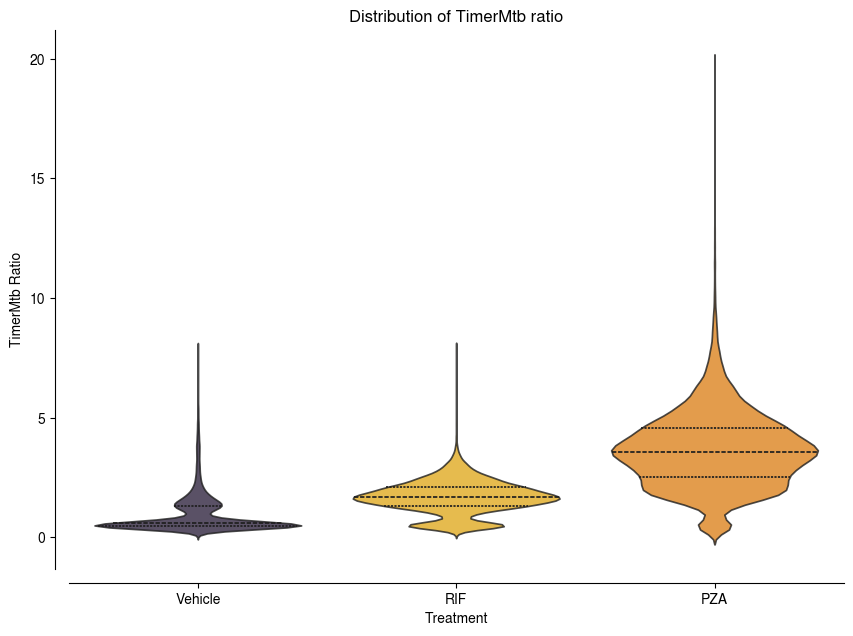

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# --- THEME CONFIGURATION ---
CORE_COLORS = {
    'Vehicle': '#312244', 
    'RIF':     '#ffb703', 
    'PZA':     '#fb8500'  
}
ORDER = ['Vehicle', 'RIF', 'PZA']

# 1. Prepare Data
mouse_means = (
    intracellular_df.groupby(['mouse_id', 'condition'])['timer_ratio']
    .mean()
    .reset_index()
)

intracellular_df['plot_condition'] = intracellular_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')
mouse_means['plot_condition'] = mouse_means['condition'].replace(['H2O', 'DMSO'], 'Vehicle')

# 2. Stronger Jitter Calculation
# Increased jitter_strength and used a normal distribution for a more natural cluster
cond_map = {cond: i for i, cond in enumerate(ORDER)}
jitter_strength = 0.15 # Adjusted for better spread within the violin width
rng = np.random.default_rng(42) # Seeded for reproducibility

# Using a normal distribution helps prevent points from stacking perfectly on the edges
mouse_means['x_jitter'] = mouse_means['plot_condition'].map(cond_map) + rng.normal(0, jitter_strength, size=len(mouse_means))

# 3. Initialize Figure
f, ax = plt.subplots(figsize=(10, 7))

# 4. Violin Plot (Cell-level distribution)
sns.violinplot(
    data=intracellular_df,
    x='plot_condition',
    y='timer_ratio',
    order=ORDER,
    palette=CORE_COLORS,
    width=0.8,
    inner='quart',
    alpha=0.8, # More transparent to make the points the focal point
    ax=ax
)

# # 5. Scatter Plot (Mouse-level means as numbered circles)
# sns.scatterplot(
#     data=mouse_means,
#     x='x_jitter',
#     y='timer_ratio',
#     hue='plot_condition',
#     hue_order=ORDER,
#     palette=CORE_COLORS,
#     marker='o',
#     s=400, # Slightly larger for better readability if points are close
#     edgecolor='black',
#     linewidth=1.5,
#     ax=ax,
#     legend=False,
#     zorder=3 
# )

# # 6. Overlay Mouse ID Numbers
# for i in range(len(mouse_means)):
#     row = mouse_means.iloc[i]
#     text_color = 'white' if row['plot_condition'] == 'Vehicle' else 'black'
    
#     ax.text(
#         x=row['x_jitter'],
#         y=row['timer_ratio'],
#         s=str(int(row['mouse_id'])),
#         fontsize=10, # Increased slightly
#         color=text_color,
#         ha='center',
#         va='center',
#         fontweight='bold',
#         zorder=4
#     )

# 7. Refine Axes
ax.set_xlabel('Treatment')
ax.set_ylabel('TimerMtb Ratio')
ax.set_title('Distribution of TimerMtb ratio')

sns.despine(offset=10)
ax.set_facecolor('white')

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/timer_ratio_per_cell.pdf', bbox_inches='tight', dpi=314)
plt.show()

/tmp/ipykernel_10732/2590925528.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intracellular_df['plot_condition'] = intracellular_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')
/tmp/ipykernel_10732/2590925528.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intracellular_df['cond_cat'] = pd.Categorical(


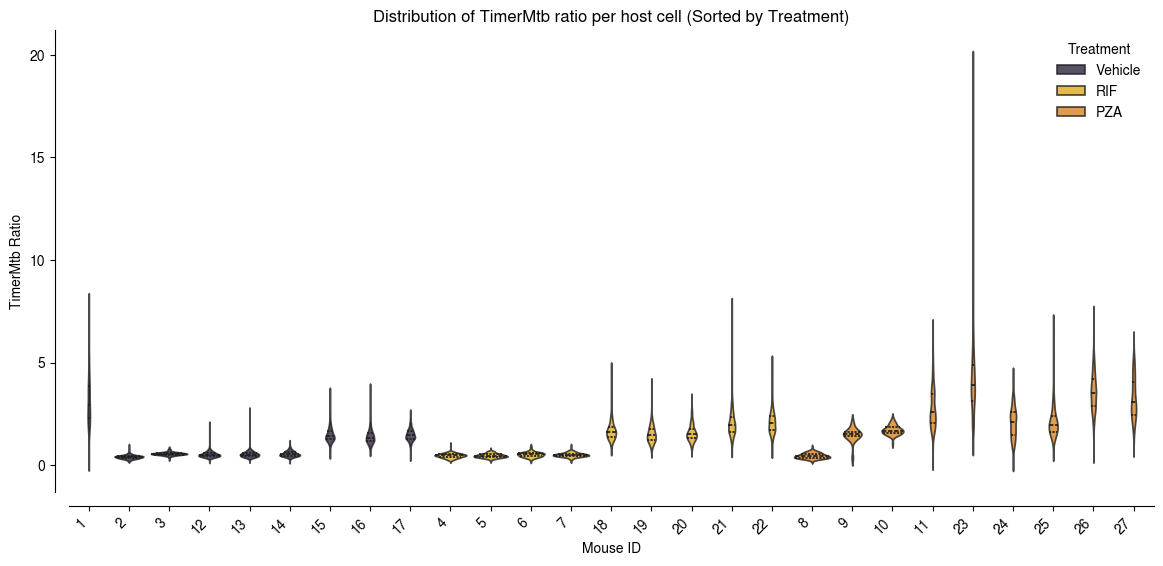

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# 1. Define Theme and Order
# Midnight & Orchid Palette
CORE_COLORS = {
    'Vehicle': '#312244', # Deep Midnight Purple
    'RIF':     '#ffb703', # Bright Yellow
    'PZA':     '#fb8500'  # Vivid Orange
}
condition_order = ['Vehicle', 'RIF', 'PZA']

# Remap and Define Order
intracellular_df['plot_condition'] = intracellular_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')

# 2. Determine Mouse Order
# Create a categorical column to enforce the specific condition order (Vehicle -> RIF -> PZA)
intracellular_df['cond_cat'] = pd.Categorical(
    intracellular_df['plot_condition'], 
    categories=condition_order, 
    ordered=True
)

# Sort by condition, then by mouse_id, and extract unique IDs in that order
mouse_order = intracellular_df.sort_values(['cond_cat', 'mouse_id'])['mouse_id'].unique()

# 3. Plot
f, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=intracellular_df, 
    x='mouse_id', 
    y='timer_ratio', 
    hue='plot_condition',      # Groups by Vehicle/RIF/PZA
    order=mouse_order,          # Applies the sorted x-axis order
    hue_order=condition_order,  # Ensures legend matches x-axis logic
    palette=CORE_COLORS, 
    width=0.9, 
    inner='quart',
    dodge=False,                # Prevents hue nesting since x is unique
    alpha=0.8,
    ax=ax
)

# 4. Final Formatting
sns.despine(offset=10)
ax.set_title('Distribution of TimerMtb ratio per host cell (Sorted by Treatment)')
ax.set_xlabel('Mouse ID')
ax.set_ylabel('TimerMtb Ratio')

plt.xticks(rotation=45, ha='right') # Rotation for readability
plt.legend(title='Treatment', loc='upper right', frameon=False)

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/timer_ratio_per_mouse_sorted_orchid.pdf', bbox_inches='tight', dpi=314)
plt.show()

In [20]:
cfu_df = pd.read_parquet('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFUs.parquet')

In [91]:
cfu_df

,rep_mouse_id,mouse_id,condition,Lung CFU (log10),rep_id,mouse_num,x_jitter,plot_condition
0,1-1,1,H2O,7.47,1,1,0.171244,Vehicle
1,1-2,2,DMSO,5.75,1,2,0.261178,Vehicle
2,1-11,3,DMSO,5.76,1,11,0.341825,Vehicle
3,1-3,4,RIF,4.87,1,3,1.313112,RIF
4,1-4,5,RIF,4.24,1,4,0.704384,RIF
5,1-5,6,RIF,4.41,1,5,1.224646,RIF
6,1-6,7,RIF,5.15,1,6,1.175292,RIF
7,1-7,8,PZA,3.78,1,7,1.963269,PZA
8,1-8,9,PZA,3.48,1,8,1.854458,PZA
9,1-9,10,PZA,3.56,1,9,2.222670,PZA


In [24]:
df.keys()

Index(['zarr_address', 'mouse_num', 'mouse_id', 'rep_id', 'split', 'host_id',
       'host_area', 'host_eccentricity', 'is_infected', 'mtb_count',
       'total_mtb_area', 'mean_mtb_ch1', 'mean_mtb_ch2', 'centroid_y',
       'centroid_x', 'bbox_minr', 'bbox_minc', 'bbox_maxr', 'bbox_maxc',
       'granuloma_region', 'exclusion_region', 'condition', 'timer_ratio'],
      dtype='object')

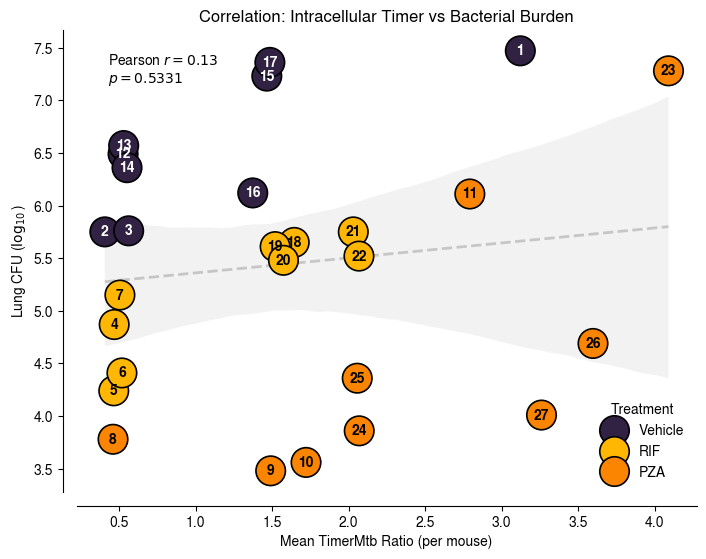

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# --- THEME CONFIGURATION ---
CORE_COLORS = {
    'Vehicle': '#312244', # Deep Midnight Purple
    'RIF':     '#ffb703', # Bright Yellow
    'PZA':     '#fb8500'  # Vivid Orange
}
order = ['Vehicle', 'RIF', 'PZA']

# 1. Aggregate Timer Ratio per Mouse
mean_timer_df = (
    intracellular_df.groupby('mouse_id')['timer_ratio']
    .mean()
    .reset_index(name='mean_timer_ratio')
)

# 2. Merge with CFU Data
merged_df = cfu_df.merge(mean_timer_df, on='mouse_id', how='inner')
merged_df['plot_condition'] = merged_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')

# 3. Calculate Correlation Statistics
r, p = stats.pearsonr(merged_df['mean_timer_ratio'], merged_df['Lung CFU (log10)'])

# 4. Plot
f, ax = plt.subplots(figsize=(8, 6))

# Regression Line (Global)
sns.regplot(
    data=merged_df,
    x='mean_timer_ratio',
    y='Lung CFU (log10)',
    scatter=False,
    color='darkgray',
    line_kws={'linestyle': '--', 'alpha': 0.6, 'linewidth': 2},
    ax=ax
)

# Scatter Points (Container circles)
sns.scatterplot(
    data=merged_df,
    x='mean_timer_ratio',
    y='Lung CFU (log10)',
    hue='plot_condition',
    hue_order=order,
    palette=CORE_COLORS,
    s=450, 
    edgecolor='black',
    linewidth=1.2,
    ax=ax,
    zorder=3
)

# 5. Overlay Mouse ID Numbers
for i in range(len(merged_df)):
    row = merged_df.iloc[i]
    # Contrast logic: White text for Midnight (Vehicle), Black for Yellow/Orange (RIF/PZA)
    text_color = 'white' if row['plot_condition'] == 'Vehicle' else 'black'
    
    ax.text(
        x=row['mean_timer_ratio'],
        y=row['Lung CFU (log10)'],
        s=str(int(row['mouse_id'])),
        fontsize=10,
        color=text_color,
        ha='center',
        va='center',
        fontweight='bold',
        zorder=4
    )

# Annotate Stats
ax.text(
    0.05, 0.95, 
    f'Pearson $r = {r:.2f}$\n$p = {p:.4f}$', 
    transform=ax.transAxes, 
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none')
)

sns.despine(offset=10)
ax.set_title('Correlation: Intracellular Timer vs Bacterial Burden')
ax.set_xlabel('Mean TimerMtb Ratio (per mouse)')
ax.set_ylabel('Lung CFU ($\log_{10}$)')
plt.legend(title='Treatment', loc='lower right', frameon=False)

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/correlation_timer_vs_cfu_orchid.pdf', bbox_inches='tight', dpi=314)
plt.show()

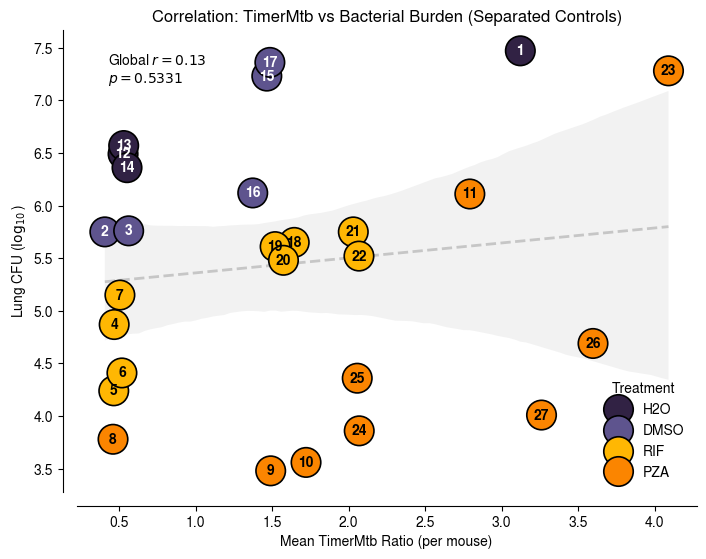

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# --- THEME CONFIGURATION ---
CORE_COLORS = {
    'H2O':  '#312244', # Deep Midnight
    'DMSO': '#5e548e', # Muted Indigo
    'RIF':  '#ffb703', # Bright Yellow
    'PZA':  '#fb8500'  # Vivid Orange
}
order = ['H2O', 'DMSO', 'RIF', 'PZA']

# 1. Aggregate Timer Ratio per Mouse
mean_timer_df = (
    intracellular_df.groupby('mouse_id')['timer_ratio']
    .mean()
    .reset_index(name='mean_timer_ratio')
)

# 2. Merge with CFU Data
merged_df = cfu_df.merge(mean_timer_df, on='mouse_id', how='inner')

# 3. Calculate Global Correlation Statistics
r, p = stats.pearsonr(merged_df['mean_timer_ratio'], merged_df['Lung CFU (log10)'])

# 4. Plot
f, ax = plt.subplots(figsize=(8, 6))

# Regression Line (Global Trend)
sns.regplot(
    data=merged_df,
    x='mean_timer_ratio',
    y='Lung CFU (log10)',
    scatter=False,
    color='darkgray',
    line_kws={'linestyle': '--', 'alpha': 0.6, 'linewidth': 2},
    ax=ax
)

# Scatter Points (Container circles)
sns.scatterplot(
    data=merged_df,
    x='mean_timer_ratio',
    y='Lung CFU (log10)',
    hue='condition',
    hue_order=order,
    palette=CORE_COLORS,
    s=450, 
    edgecolor='black',
    linewidth=1.2,
    ax=ax,
    zorder=3
)

# 5. Overlay Mouse ID Numbers
for i in range(len(merged_df)):
    row = merged_df.iloc[i]
    # Contrast logic: White text for the dark purple controls, black for yellow/orange
    text_color = 'white' if row['condition'] in ['H2O', 'DMSO'] else 'black'
    
    ax.text(
        x=row['mean_timer_ratio'],
        y=row['Lung CFU (log10)'],
        s=str(int(row['mouse_id'])),
        fontsize=10,
        color=text_color,
        ha='center',
        va='center',
        fontweight='bold',
        zorder=4
    )

# Annotate Stats
ax.text(
    0.05, 0.95, 
    f'Global $r = {r:.2f}$\n$p = {p:.4f}$', 
    transform=ax.transAxes, 
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none')
)

sns.despine(offset=10)
ax.set_title('Correlation: TimerMtb vs Bacterial Burden (Separated Controls)')
ax.set_xlabel('Mean TimerMtb Ratio (per mouse)')
ax.set_ylabel('Lung CFU ($\log_{10}$)')
plt.legend(title='Treatment', loc='lower right', frameon=False)

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/correlation_timer_vs_cfu_separated_orchid.pdf', bbox_inches='tight', dpi=314)
plt.show()

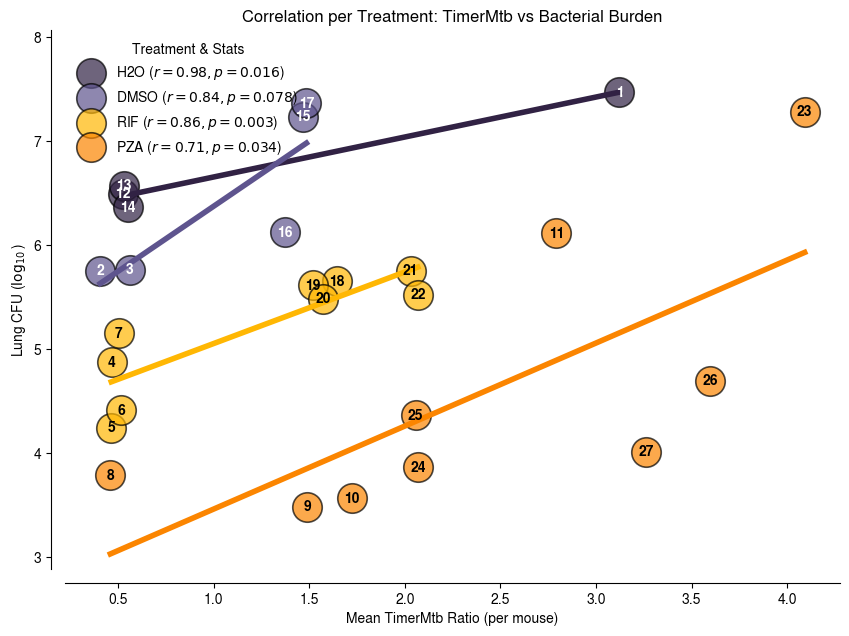

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# --- THEME CONFIGURATION ---
CORE_COLORS = {
    'H2O':  '#312244', # Deep Midnight
    'DMSO': '#5e548e', # Muted Indigo
    'RIF':  '#ffb703', # Bright Yellow
    'PZA':  '#fb8500'  # Vivid Orange
}
order = ['H2O', 'DMSO', 'RIF', 'PZA']

# 1. Aggregate and Merge
mean_timer_df = (
    intracellular_df.groupby('mouse_id')['timer_ratio']
    .mean()
    .reset_index(name='mean_timer_ratio')
)
merged_df = cfu_df.merge(mean_timer_df, on='mouse_id', how='inner')

# 2. Plot
f, ax = plt.subplots(figsize=(10, 7))

for cond in order:
    subset = merged_df[merged_df['condition'] == cond]
    
    # Calculate stats for the individual legend labels
    if len(subset) > 1:
        r, p = stats.pearsonr(subset['mean_timer_ratio'], subset['Lung CFU (log10)'])
        label_str = f"{cond} ($r={r:.2f}, p={p:.3f}$)"
    else:
        label_str = cond
    
    # Plot regression with bold orchid/midnight lines
    sns.regplot(
        data=subset,
        x='mean_timer_ratio',
        y='Lung CFU (log10)',
        ax=ax,
        color=CORE_COLORS[cond],
        label=label_str,
        scatter_kws={'s': 450, 'edgecolor': 'black', 'linewidths': 1.2, 'alpha': 0.7},
        line_kws={'linewidth': 4, 'alpha': 1.0},
        truncate=True, 
        ci=None
    )

# 3. Add mouse_id labels with contrast logic
for i in range(merged_df.shape[0]):
    row = merged_df.iloc[i]
    # Contrast: White text for dark purples, black for yellow/orange
    text_color = 'white' if row['condition'] in ['H2O', 'DMSO'] else 'black'
    
    ax.text(
        x=row['mean_timer_ratio'],
        y=row['Lung CFU (log10)'],
        s=str(int(row['mouse_id'])),
        fontsize=10,
        color=text_color,
        ha='center',
        va='center',
        fontweight='bold',
        zorder=5 # Ensure text stays above lines and markers
    )

# 4. Formatting
y_max, y_min = merged_df['Lung CFU (log10)'].max(), merged_df['Lung CFU (log10)'].min()
padding = (y_max - y_min) * 0.15
ax.set_ylim(max(0, y_min - padding), y_max + padding)

sns.despine(offset=10)
ax.set_title('Correlation per Treatment: TimerMtb vs Bacterial Burden')
ax.set_xlabel('Mean TimerMtb Ratio (per mouse)')
ax.set_ylabel('Lung CFU ($\log_{10}$)')

# Legend now contains all the statistical info
ax.legend(title='Treatment & Stats', loc='upper left', frameon=False, fontsize=10)

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/correlation_timer_vs_cfu_per_condition_orchid_legend_stats.pdf', bbox_inches='tight', dpi=314)
plt.show()

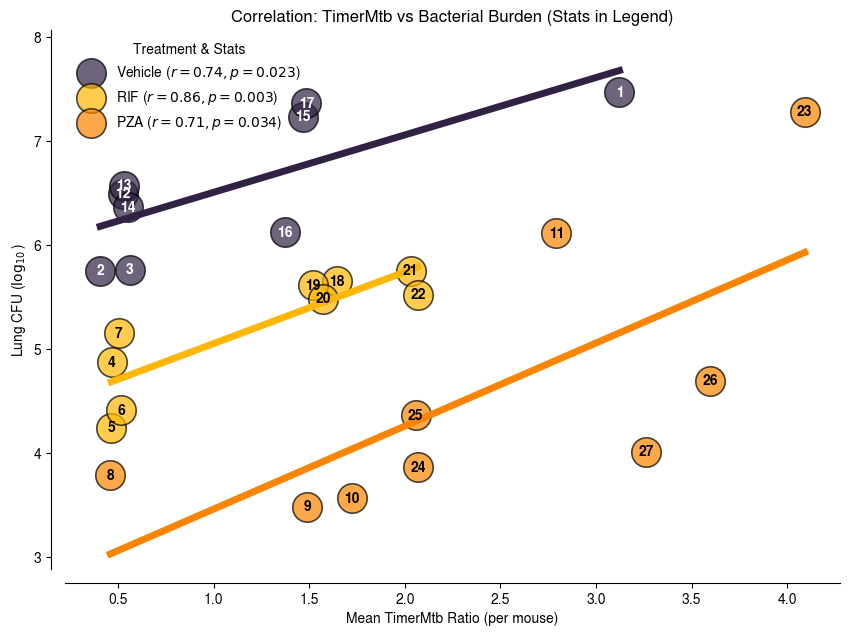

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set font for Ubuntu
plt.rcParams['font.family'] = 'Nimbus Sans'

# --- THEME CONFIGURATION ---
CORE_COLORS = {
    'Vehicle': '#312244', 
    'RIF':     '#ffb703', 
    'PZA':     '#fb8500'  
}
order = ['Vehicle', 'RIF', 'PZA']

# 1. Aggregate and Merge
mean_timer_df = (
    intracellular_df.groupby('mouse_id')['timer_ratio']
    .mean()
    .reset_index(name='mean_timer_ratio')
)
merged_df = cfu_df.merge(mean_timer_df, on='mouse_id', how='inner')
merged_df['plot_condition'] = merged_df['condition'].replace(['H2O', 'DMSO'], 'Vehicle')

# 2. Plot
f, ax = plt.subplots(figsize=(10, 7))

for cond in order:
    subset = merged_df[merged_df['plot_condition'] == cond]
    
    # Calculate stats for the legend label
    if len(subset) > 1:
        r, p = stats.pearsonr(subset['mean_timer_ratio'], subset['Lung CFU (log10)'])
        # Create a combined label for the legend
        label_str = f"{cond} ($r={r:.2f}, p={p:.3f}$)"
    else:
        label_str = cond

    # Plot regression
    sns.regplot(
        data=subset,
        x='mean_timer_ratio',
        y='Lung CFU (log10)',
        ax=ax,
        color=CORE_COLORS[cond],
        label=label_str, # Injects stats into the legend
        scatter_kws={'s': 450, 'edgecolor': 'black', 'linewidths': 1.2, 'alpha': 0.7},
        line_kws={'linewidth': 5, 'alpha': 1.0},
        truncate=True, 
        ci=None
    )

# 3. Add mouse_id labels
for i in range(merged_df.shape[0]):
    row = merged_df.iloc[i]
    text_color = 'white' if row['plot_condition'] == 'Vehicle' else 'black'
    
    ax.text(
        x=row['mean_timer_ratio'],
        y=row['Lung CFU (log10)'],
        s=str(int(row['mouse_id'])),
        fontsize=10,
        color=text_color,
        ha='center',
        va='center',
        fontweight='bold',
        zorder=5
    )

# 4. Formatting
y_max, y_min = merged_df['Lung CFU (log10)'].max(), merged_df['Lung CFU (log10)'].min()
padding = (y_max - y_min) * 0.15
ax.set_ylim(max(0, y_min - padding), y_max + padding)

sns.despine(offset=10)
ax.set_title('Correlation: TimerMtb vs Bacterial Burden (Stats in Legend)')
ax.set_xlabel('Mean TimerMtb Ratio (per mouse)')
ax.set_ylabel('Lung CFU ($\log_{10}$)')

# Move legend to the best location or outside if it overlaps
ax.legend(title='Treatment & Stats', loc='upper left', frameon=False, fontsize=10)

plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/correlation_timer_vs_cfu_legend_stats.pdf', bbox_inches='tight', dpi=314)
plt.show()

# Load previously calculated results

In [2]:
df = pd.read_pickle('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/host_sc_mtb_tissue.pkl')

In [5]:
metadata = pd.read_pickle('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/arx/metadata.pkl')

In [10]:
# Rename specific columns using a dictionary
# Format: {'old_name': 'new_name'}
metadata = metadata.rename(columns={
    'mouse_num': 'mouse_N',
    'replicate': 'rep_N',
})

In [11]:
metadata.keys()

Index(['mouse_N', 'rep_N', 'condition', 'basename_stem'], dtype='object')

In [12]:
# 1. Select only the columns you need from metadata to avoid duplicates
cols_to_merge = ['mouse_N', 'rep_N', 'condition']

# 2. Perform the merge
merged_df = df.merge(
    metadata[cols_to_merge], 
    on=['mouse_N', 'rep_N'], 
    how='left'
)

In [14]:
metadata

,mouse_N,rep_N,condition,basename_stem
0,1,1,H2O,20250815_40X_TimerMtb_BP_mice1_DAPI_TimerG_Tim...
1,2,1,DMSO,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...
2,3,1,RIF,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...
3,4,1,RIF,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...
4,5,1,RIF,20250901_40X_TimerMtb_BP_mice5_mice6_mice7_DAP...
5,6,1,RIF,20250901_40X_TimerMtb_BP_mice5_mice6_mice7_DAP...
6,7,1,PZA,20250901_40X_TimerMtb_BP_mice5_mice6_mice7_DAP...
7,8,1,PZA,20250821_40X_TimerMtb_BP_mice8_mice9_DAPI_Time...
8,9,1,PZA,20250821_40X_TimerMtb_BP_mice8_mice9_DAPI_Time...
9,10,1,PZA,20250814_40X_TimerMtb_BP_mice10_DAPI_TimerG_Ti...


In [13]:
merged_df

,zarr_address,rep_N,mouse_N,split,host_cell_id,host_area,host_eccentricity,host_bbox,total_mtb_area,avg_mtb_int_ch1,avg_mtb_int_ch2,mtb_count,condition
0,20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice...,2,1,None,1,5425.0,0.449241,"[4026, 18526, 4109, 18603]",0.0,0.0,0.0,0.0,H2O
1,20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice...,2,1,None,2,7266.0,0.414785,"[4076, 17907, 4171, 18000]",0.0,0.0,0.0,0.0,H2O
2,20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice...,2,1,None,3,5254.0,0.614989,"[4109, 18517, 4180, 18606]",0.0,0.0,0.0,0.0,H2O
3,20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice...,2,1,None,4,7813.0,0.644991,"[4248, 18560, 4337, 18673]",0.0,0.0,0.0,0.0,H2O
4,20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice...,2,1,None,5,5289.0,0.342725,"[4331, 17947, 4411, 18027]",0.0,0.0,0.0,0.0,H2O
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5611056,rep1_mouse10_right.zarr,1,10,RIGHT,175793,5958.0,0.522265,"[35386, 30357, 35469, 30443]",0.0,0.0,0.0,0.0,PZA
5611057,rep1_mouse10_right.zarr,1,10,RIGHT,175794,4293.0,0.451464,"[35411, 29681, 35487, 29768]",0.0,0.0,0.0,0.0,PZA
5611058,rep1_mouse10_right.zarr,1,10,RIGHT,175795,6674.0,0.687811,"[35639, 28985, 35719, 29089]",0.0,0.0,0.0,0.0,PZA
5611059,rep1_mouse10_right.zarr,1,10,RIGHT,175796,6691.0,0.477855,"[35694, 29191, 35780, 29286]",0.0,0.0,0.0,0.0,PZA


In [7]:
df[['mouse_N', 'rep_N']].drop_duplicates()

,mouse_N,rep_N
0,1,2
155194,2,2
313415,3,2
567956,4,2
847044,5,2
1084270,6,2
1267025,7,2
1462204,8,2
1637280,9,2
1824388,10,2


In [3]:
df

,zarr_address,rep_N,mouse_N,split,host_cell_id,host_area,host_eccentricity,host_bbox,total_mtb_area,avg_mtb_int_ch1,avg_mtb_int_ch2,mtb_count
0,20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice...,2,1,None,1,5425.0,0.449241,"[4026, 18526, 4109, 18603]",0.0,0.0,0.0,0.0
1,20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice...,2,1,None,2,7266.0,0.414785,"[4076, 17907, 4171, 18000]",0.0,0.0,0.0,0.0
2,20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice...,2,1,None,3,5254.0,0.614989,"[4109, 18517, 4180, 18606]",0.0,0.0,0.0,0.0
3,20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice...,2,1,None,4,7813.0,0.644991,"[4248, 18560, 4337, 18673]",0.0,0.0,0.0,0.0
4,20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice...,2,1,None,5,5289.0,0.342725,"[4331, 17947, 4411, 18027]",0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5611056,rep1_mouse10_right.zarr,1,10,RIGHT,175793,5958.0,0.522265,"[35386, 30357, 35469, 30443]",0.0,0.0,0.0,0.0
5611057,rep1_mouse10_right.zarr,1,10,RIGHT,175794,4293.0,0.451464,"[35411, 29681, 35487, 29768]",0.0,0.0,0.0,0.0
5611058,rep1_mouse10_right.zarr,1,10,RIGHT,175795,6674.0,0.687811,"[35639, 28985, 35719, 29089]",0.0,0.0,0.0,0.0
5611059,rep1_mouse10_right.zarr,1,10,RIGHT,175796,6691.0,0.477855,"[35694, 29191, 35780, 29286]",0.0,0.0,0.0,0.0


# Plot

In [62]:
merged_df.keys()

Index(['zarr_address', 'rep_N', 'mouse_N', 'split', 'host_cell_id',
       'host_area', 'host_eccentricity', 'host_bbox', 'total_mtb_area',
       'avg_mtb_int_ch1', 'avg_mtb_int_ch2', 'mtb_count', 'condition'],
      dtype='object')

In [58]:
df.keys()

Index(['zarr_address', 'rep_N', 'mouse_N', 'split', 'host_cell_id',
       'host_area', 'host_eccentricity', 'host_bbox', 'total_mtb_area',
       'avg_mtb_int_ch1', 'avg_mtb_int_ch2', 'mtb_count'],
      dtype='object')

In [100]:
df = merged_df

In [103]:
df['timer']=df['avg_mtb_int_ch1']/df['avg_mtb_int_ch2']

In [101]:
df['Is_Infected'] = df['total_mtb_area'] > 0

In [102]:

percent_infected_df = df.groupby(['condition', 'mouse_N', 'rep_N']).agg(
    Infected_Count=('Is_Infected', 'sum'),
    Total_Cells=('condition', 'size')
).reset_index()

percent_infected_df['Percent_Infected'] = (
    percent_infected_df['Infected_Count'] / percent_infected_df['Total_Cells']
) * 100

In [70]:
percent_infected_df

,condition,mouse_N,rep_N,Infected_Count,Total_Cells,Percent_Infected
0,DMSO,2,1,535,155692,0.343627
1,DMSO,4,2,1549,279088,0.555022
2,DMSO,5,2,987,237226,0.416059
3,DMSO,6,2,664,182755,0.363328
4,DMSO,11,1,163,192587,0.084637
5,H2O,1,1,77,156366,0.049243
6,H2O,1,2,11405,155194,7.348867
7,H2O,2,2,1605,158221,1.014404
8,H2O,3,2,1488,254541,0.584582
9,PZA,7,1,527,185595,0.283952


In [121]:
percent_infected_df['Total_Cells'].sum()

np.int64(5611061)

In [122]:
percent_infected_df['Infected_Count'].sum()

np.int64(57245)

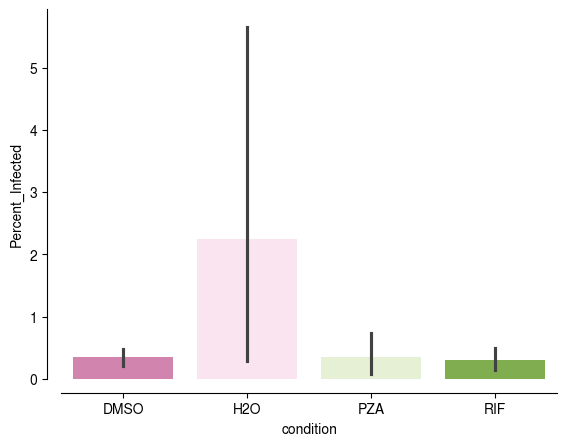

In [77]:
sns.barplot(data=percent_infected_df, y='Percent_Infected', x='condition', hue='condition', palette='PiYG')
sns.despine(offset=10)

/tmp/ipykernel_704808/513246451.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('PiYG')
/tmp/ipykernel_704808/513246451.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


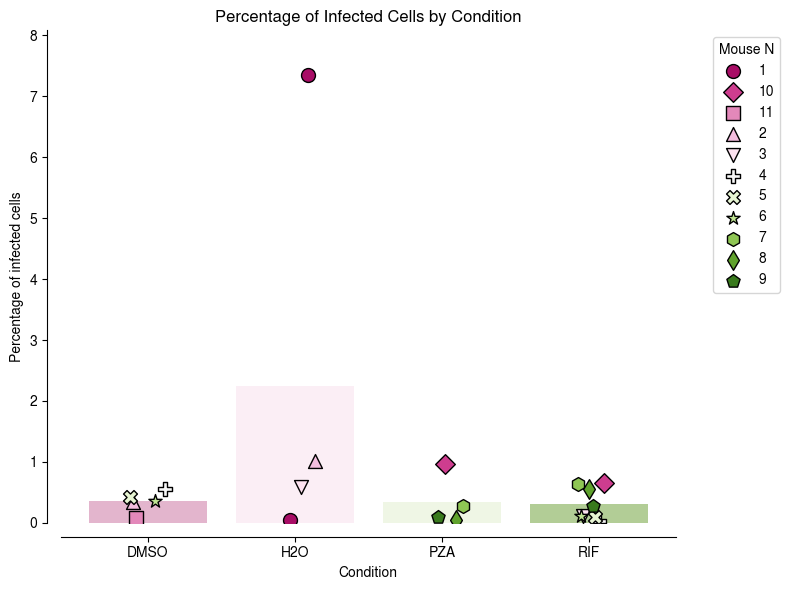

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Create the DataFrame
data = {
    'condition': ['DMSO', 'DMSO', 'DMSO', 'DMSO', 'DMSO', 'H2O', 'H2O', 'H2O', 'H2O', 'PZA', 'PZA', 'PZA', 'PZA', 'RIF', 'RIF', 'RIF', 'RIF', 'RIF', 'RIF', 'RIF', 'RIF'],
    'mouse_N': [2, 4, 5, 6, 11, 1, 1, 2, 3, 7, 8, 9, 10, 3, 4, 5, 6, 7, 8, 9, 10],
    'Percent_Infected': [0.343627, 0.555022, 0.416059, 0.363328, 0.084637, 0.049243, 7.348867, 1.014404, 0.584582, 0.283952, 0.044835, 0.101187, 0.958884, 0.113378, 0.021977, 0.103316, 0.107622, 0.643512, 0.555759, 0.282724, 0.654603]
}
df = pd.DataFrame(data)
df['mouse_N'] = df['mouse_N'].astype(str)

# Define the plot order
order = ['DMSO', 'H2O', 'PZA', 'RIF']
unique_mice = sorted(df['mouse_N'].unique())
n_mice = len(unique_mice)

# Map x-axis labels to numerical positions for jitter
condition_to_x = {cond: i for i, cond in enumerate(order)}
df['x_pos'] = df['condition'].map(condition_to_x)

# Define custom markers and colors
markers = ['o', 'D', 's', '^', 'v', 'P', 'X', '*', 'h', 'd', 'p'] 
cmap = cm.get_cmap('PiYG')
colors = [cmap(i) for i in np.linspace(0.05, 0.95, n_mice)] 

# Create mappings
mouse_to_marker = {mouse: marker for mouse, marker in zip(unique_mice, markers)}
mouse_to_color = {mouse: color for mouse, color in zip(unique_mice, colors)}

# Create the plot
plt.figure(figsize=(8, 6))

# A. Bar Plot (for the average)
sns.barplot(
    data=df,
    x='condition',
    y='Percent_Infected',
    order=order,
    errorbar=None,
    palette='PiYG',
    alpha=0.6,
    zorder=1,
)

# B. Scatter Plot (for individual points) using manual loop
legend_handles = []
for mouse_id in unique_mice:
    df_mouse = df[df['mouse_N'] == mouse_id].copy()
    
    # Add jitter to the x-position
    jitter = np.random.uniform(-0.15, 0.15, len(df_mouse))
    df_mouse['jittered_x'] = df_mouse['x_pos'] + jitter
    
    # Plot the points
    scatter = plt.scatter(
        df_mouse['jittered_x'],
        df_mouse['Percent_Infected'],
        label=mouse_id,
        marker=mouse_to_marker[mouse_id],
        color=mouse_to_color[mouse_id],
        s=100, # size of marker
        edgecolor='black',
        linewidth=1,
        zorder=2
    )
    legend_handles.append(scatter)

# 5. Customize the plot
plt.title('Percentage of Infected Cells by Condition')
plt.ylabel('Percentage of infected cells')
plt.xlabel('Condition')
plt.ylim(0, df['Percent_Infected'].max() * 1.1)

# Set x-ticks and labels correctly
plt.xticks(list(condition_to_x.values()), order)

# Create legend using the collected handles
plt.legend(legend_handles, unique_mice, title='Mouse N', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(offset=10)
plt.tight_layout()
plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/percentage_infected.pdf', bbox_inches='tight', dpi=314)

<Axes: xlabel='total_mtb_area', ylabel='Count'>

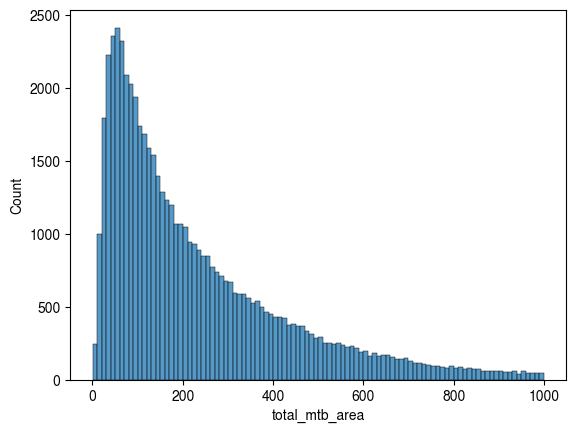

In [86]:
sns.histplot(merged_df[(merged_df['total_mtb_area']<1000) & (merged_df['total_mtb_area']>0) ]['total_mtb_area'], bins = 100)
# plt.ylim(0)

In [104]:
# Assuming your raw data is in a DataFrame called df_raw
import numpy as np

# Define your actual cutoffs here
LOW_CUTOFF = 10
MED_CUTOFF = 100.0

# Create the categories
bins = [-np.inf, 0, LOW_CUTOFF, MED_CUTOFF, np.inf]
labels = ['Uninfected', 'Low', 'Medium', 'High']

# Use pd.cut to assign categories
df['Burden_Category'] = pd.cut(
    df['total_mtb_area'],
    bins=bins,
    labels=labels,
    right=True # Intervals include the right endpoint (e.g., <= 5.0)
)

# # Plotting the stacked bar chart for Low, Medium, High burden
# plt.figure(figsize=(10, 6))

# # Define the order and colors
# condition_order = ['DMSO', 'H2O', 'PZA', 'RIF']
# burden_order = ['Low', 'Medium', 'High']

# # Use a specific palette for the burden categories
# burden_palette = {'Low': 'lightgreen', 'Medium': 'lightgray', 'High': 'magenta'}

# # Create the stacked bar plot
# sns.barplot(
#     data=df,
#     x='condition',
#     y='Percent',
#     hue='condition',
#     hue_order=burden_order,
#     order=condition_order,
#     palette=burden_palette,
#     errorbar=None, # Showing mean percentage
#     dodge=False, # This ensures the bars are stacked
# )

# # Customization
# plt.title('Percentage of Infected Cells (by Burden) per Treatment')
# plt.ylabel('Percentage of Infected Cells (Total)')
# plt.xlabel('Condition')
# plt.legend(title='Infection Burden')
# plt.tight_layout()
# plt.show()

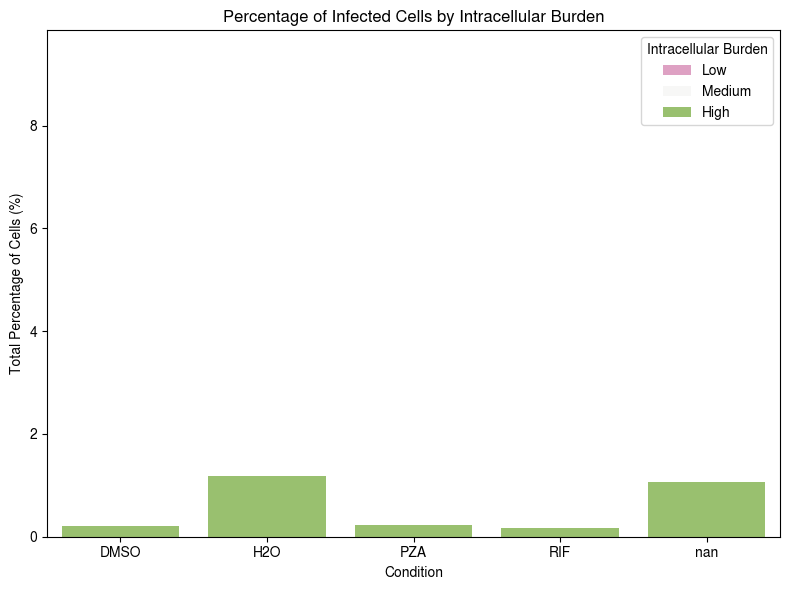

In [96]:
# 1. Define the palette for the burden categories using PiYG
# We explicitly sample 3 distinct colors from the PiYG colormap
piyg_colors = sns.color_palette('PiYG', n_colors=3)

# Create a dictionary mapping the categories to the specific colors
burden_color_map = {
    'Low': piyg_colors[0],  # Usually the lighter/yellow-green side
    'Medium': piyg_colors[1], # The middle color
    'High': piyg_colors[2]   # Usually the darker/magenta side
}

# 2. Plotting the Stacked Bar Chart (Mean Percentages)

plt.figure(figsize=(8, 6))

# Define plot order for conditions
condition_order = sorted(df_burden_infected['condition'].unique())

# Create the stacked bar plot (showing the mean percentage contribution)
sns.barplot(
    data=df_burden_infected,
    x='condition',
    y='Percent',
    hue='Burden_Category',
    hue_order=burden_order,
    order=condition_order,
    palette=burden_color_map, # Use the explicit color map dictionary
    errorbar=None,
    dodge=False, # ESSENTIAL for stacking the bars
    zorder=1
)

# Customization
plt.title('Percentage of Infected Cells by Intracellular Burden')
plt.ylabel('Total Percentage of Cells (%)')
plt.xlabel('Condition')
plt.legend(title='Intracellular Burden', loc='upper right')

# Set y-limit based on the highest total percentage of infected cells
max_percent = df_burden_infected.groupby('condition')['Percent'].sum().max()
plt.ylim(0, max_percent * 1.1)

plt.tight_layout()
# plt.savefig('burden_stacked_bar_plot_colored.png')
# print("burden_stacked_bar_plot_colored.png")

In [107]:
# --- STEP 1: CALCULATE THE AVERAGE TIMER VALUE PER REPLICATE ---

# Ensure the grouping columns are strings for safe merging
df['condition'] = df['condition'].astype(str)
df['mouse_N'] = df['mouse_N'].astype(str)

# Calculate the average (mean) of the timer_value for each replicate (condition + mouse_N)
df_avg_timer = df.groupby(['condition', 'mouse_N'])['timer'].mean().reset_index()

# Rename the new column clearly
df_avg_timer.rename(columns={'timer': 'Avg_Timer_Value'}, inplace=True)

# --- STEP 2: MERGE INTO THE PERCENTAGE DATAFRAME ---

# Ensure the percentage DataFrame columns are strings for safe merging
df_percent['condition'] = df_percent['condition'].astype(str)
df_percent['mouse_N'] = df_percent['mouse_N'].astype(str)

# Merge the average timer values into the percentage DataFrame
df_percent_merged = pd.merge(
    df_percent, 
    df_avg_timer, 
    on=['condition', 'mouse_N'], 
    how='left' # Use a left merge to keep all rows from your percentage DF
)

# Display the head of the new merged DataFrame
print(df_percent_merged.head())

NameError: name 'df_percent' is not defined

In [98]:
df['timer'] = df['avg_mtb_int_ch1']/df['avg_mtb_int_ch2']

In [115]:
df.keys()

Index(['zarr_address', 'rep_N', 'mouse_N', 'split', 'host_cell_id',
       'host_area', 'host_eccentricity', 'host_bbox', 'total_mtb_area',
       'avg_mtb_int_ch1', 'avg_mtb_int_ch2', 'mtb_count', 'condition',
       'Is_Infected', 'Burden_Category', 'timer'],
      dtype='object')

/tmp/ipykernel_704808/1232613161.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df[(df['condition']!='nan') & (df['Is_Infected']==True)],


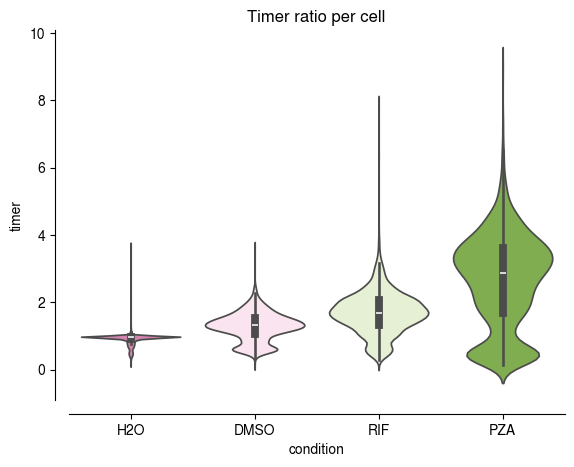

In [120]:
sns.violinplot(data=df[(df['condition']!='nan') & (df['Is_Infected']==True)], 
               x='condition', y='timer', palette='PiYG', width=0.8,)
sns.despine(offset=10)
plt.title('Timer ratio per cell')
plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/timer_ratio_per_cell.pdf', bbox_inches='tight', dpi=314)

Text(0.5, 1.0, 'Timer ratio per cell')

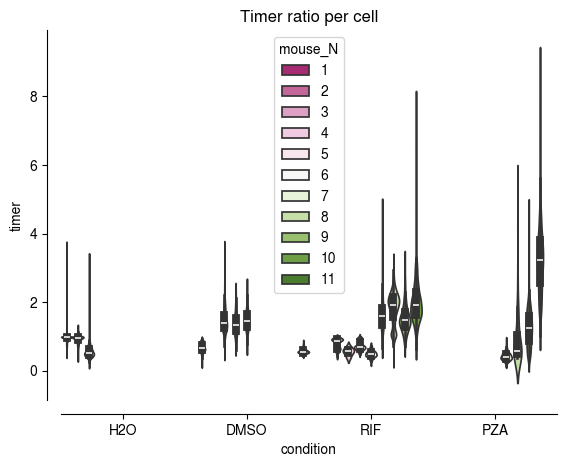

In [124]:
sns.violinplot(data=df[(df['condition']!='nan') & (df['Is_Infected']==True)], 
               x='condition', y='timer', palette='PiYG', hue='mouse_N', width=1,)
sns.despine(offset=10)
plt.title('Timer ratio per cell')

### CFUs

In [27]:
rep1 = pd.DataFrame({
    'Treatment': ['H2O', 'DMSO', 'DMSO', 'RIF', 'RIF', 'RIF', 'RIF', 'PZA', 'PZA', 'PZA', 'PZA'],
    # 'Color': ['black', 'black', 'black', 'red', 'blue', 'black', 'green', 'orange', 'pink', 'purple', 'yellow'],
    'Lung CFU (log10)': [7.47, 5.73, 5.73, 4.88, 4.23, 5.16, 4.42, 3.48, 6.10, 3.73, 3.55],
    'rep_N': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'mouse_N': [1, 2, 11, 3, 4, 6, 5, 8, 10, 7, 9]
})
rep2 = pd.DataFrame({
    'mouse_N': [3, 2, 1, 6, 5, 4, 9, 10, 11, 8, 7, 13, 12, 15, 14, 16],
    'Treatment': [
        'H2O', 'H2O', 'H2O', 
        'DMSO', 'DMSO', 'DMSO', 
        'RIF', 'RIF', 'RIF', 'RIF', 'RIF', 
        'PZA', 'PZA', 'PZA', 'PZA', 'PZA'
    ],
    # 'Color': [
    #     'red', None, None,    # Water Group (Mice 3, 2, 1)
    #     'black', 'green', 'blue', # DMSO Group (Mice 6, 5, 4)
    #     'yellow', 'pink', None, 'orange', 'purple', # RIF Group (Mice 9, 10, 11, 8, 7)
    #     None, None, None, None, None # PZA Group (Mice 13-16)
    # ],
    'Lung CFU (log10)': [6.36, 6.57, 6.50, 7.36, 6.12, 7.23, 5.47, 5.74, 6.52, 5.61, 5.64, 3.85, 7.29, 4.67, 4.36, 4.01],
    'rep_N': [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
})


cfu_df = pd.concat([rep1, rep2])
cfu_df

,Treatment,Lung CFU (log10),rep_N,mouse_N
0,H2O,7.47,1,1
1,DMSO,5.73,1,2
2,DMSO,5.73,1,11
3,RIF,4.88,1,3
4,RIF,4.23,1,4
5,RIF,5.16,1,6
6,RIF,4.42,1,5
7,PZA,3.48,1,8
8,PZA,6.10,1,10
9,PZA,3.73,1,7


In [29]:
import seaborn as sns

In [57]:
cfu_df.to_parquet('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFUs.parquet')

/tmp/ipykernel_704808/3654059405.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3654059405.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3654059405.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3654059405.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3654059405.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3654059405.py:48: FutureWarning: Use "auto" to set automatic grayscale colors.

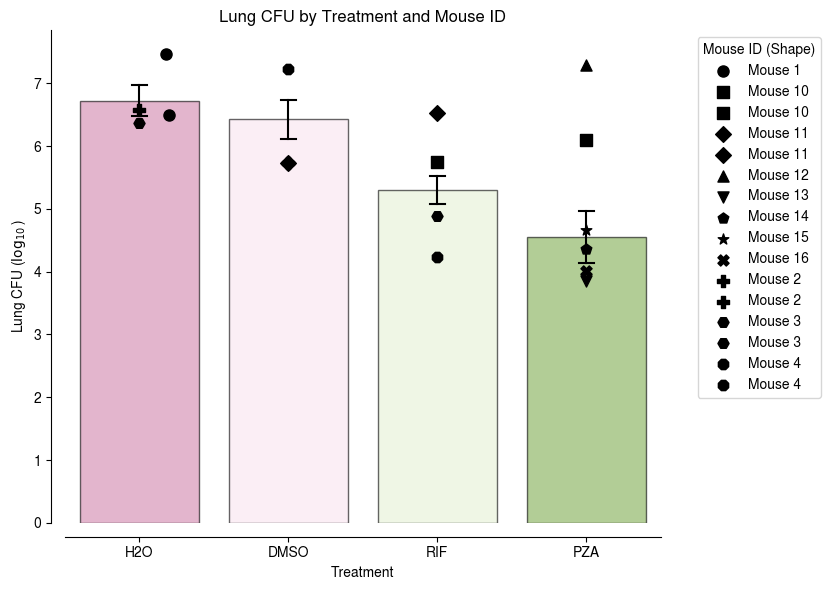

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Prepare Data and Mappings ---

# Get unique 'mouse_N' values and ensure they are strings for robust mapping
mouse_N_values = sorted(cfu_df['mouse_N'].astype(str).unique())

# Define the markers you want to use. Make sure this list is long enough
# for all your unique 'mouse_N' values.
all_markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X', 'P', 'H', '8']

# Create a dictionary to map 'mouse_N' value -> marker shape
marker_map = dict(zip(mouse_N_values, all_markers[:len(mouse_N_values)]))

# --- 2. Setup Plot ---

plt.figure(figsize=(10, 6))
ax = plt.gca()

# 1. Bar Plot for the mean (Average CFU per Treatment)
# Set hue to 'Treatment' so the bar colors are based on the x-axis groups.
sns.barplot(
    data=cfu_df,
    x='Treatment',
    y='Lung CFU (log10)',
    hue='Treatment',  # Use treatment for hue to get colored bars
    ax=ax,
    errorbar=('ci', 68),
    capsize=0.1,
    alpha=0.6,
    err_kws={'color': 'black', 'linewidth': 1.5},
    edgecolor='black',
    linewidth=1,
    # hue='Treatment',
    palette='PiYG', # Optional: uncomment if you want a specific color palette
    legend=False # Hide the barplot legend
)

# 2. Scatter Plot for individual data points (Iterating for manual style)
# We need to iterate over mouse_N groups to set the 'marker' shape
for mouse_n_val, marker_shape in marker_map.items():
    
    # Filter data for the current mouse_N
    subset_data = cfu_df[cfu_df['mouse_N'].astype(str) == mouse_n_val]
    
    # Plot the subset with the specified marker
    sns.stripplot(
        data=subset_data,
        x='Treatment',
        y='Lung CFU (log10)',
        ax=ax,
        color='black',       # Use a single color for points, or use a hue column here if desired
        size=8,
        jitter=0.2,
        linewidth=1,
        marker=marker_shape, # <-- THIS IS THE KEY MANUAL STEP
        edgecolor='gray',
        # Add a label for the legend (only one label per mouse_n_val)
        label=f'Mouse {mouse_n_val}' 
    )

# --- 3. Legend Cleanup ---

# The stripplots already generated a legend entry via the 'label' argument.
# We just need to finalize and position it.
ax.legend(
    title='Mouse ID (Shape)', 
    loc='upper left', 
    bbox_to_anchor=(1.05, 1)
)
sns.despine(offset=10)
# Final Touchesa
plt.title('Lung CFU by Treatment and Mouse ID')
plt.xlabel('Treatment')
plt.ylabel('Lung CFU ($\log_{10}$)')
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust to fit the legend
plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFU_mouse_marker_style_separation.pdf', bbox_inches='tight', dpi=314)

plt.show()

/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/3492075298.py:48: FutureWarning: Use "auto" to set automatic grayscale colors.

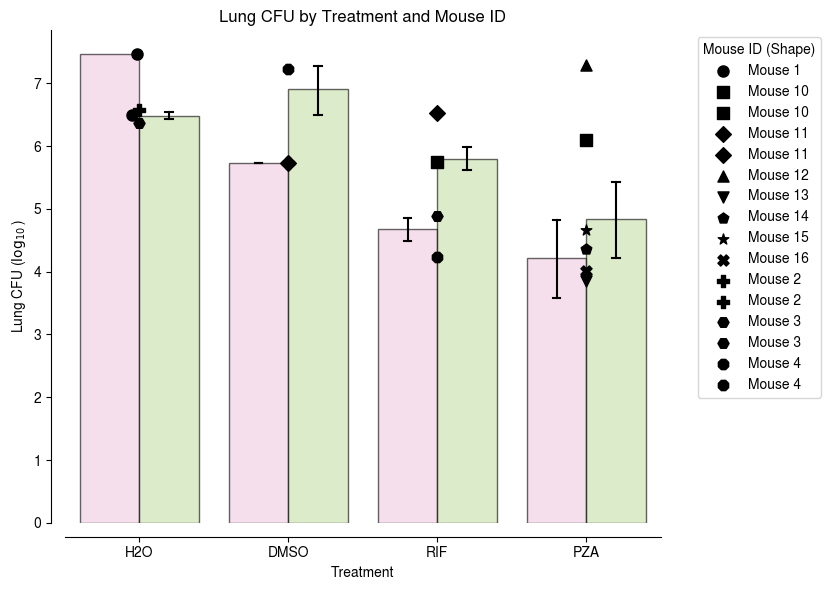

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Prepare Data and Mappings ---

# Get unique 'mouse_N' values and ensure they are strings for robust mapping
mouse_N_values = sorted(cfu_df['mouse_N'].astype(str).unique())

# Define the markers you want to use. Make sure this list is long enough
# for all your unique 'mouse_N' values.
all_markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X', 'P', 'H', '8']

# Create a dictionary to map 'mouse_N' value -> marker shape
marker_map = dict(zip(mouse_N_values, all_markers[:len(mouse_N_values)]))

# --- 2. Setup Plot ---

plt.figure(figsize=(10, 6))
ax = plt.gca()

# 1. Bar Plot for the mean (Average CFU per Treatment)
# Set hue to 'Treatment' so the bar colors are based on the x-axis groups.
sns.barplot(
    data=cfu_df,
    x='Treatment',
    y='Lung CFU (log10)',
    hue='rep_N',  # Use treatment for hue to get colored bars
    ax=ax,
    errorbar=('ci', 68),
    capsize=0.1,
    alpha=0.6,
    err_kws={'color': 'black', 'linewidth': 1.5},
    edgecolor='black',
    linewidth=1,
    # hue='Treatment',
    palette='PiYG', # Optional: uncomment if you want a specific color palette
    legend=False # Hide the barplot legend
)

# 2. Scatter Plot for individual data points (Iterating for manual style)
# We need to iterate over mouse_N groups to set the 'marker' shape
for mouse_n_val, marker_shape in marker_map.items():
    
    # Filter data for the current mouse_N
    subset_data = cfu_df[cfu_df['mouse_N'].astype(str) == mouse_n_val]
    
    # Plot the subset with the specified marker
    sns.stripplot(
        data=subset_data,
        x='Treatment',
        y='Lung CFU (log10)',
        ax=ax,
        color='black',       # Use a single color for points, or use a hue column here if desired
        size=8,
        jitter=0.2,
        linewidth=1,
        marker=marker_shape, # <-- THIS IS THE KEY MANUAL STEP
        edgecolor='gray',
        # Add a label for the legend (only one label per mouse_n_val)
        label=f'Mouse {mouse_n_val}' 
    )

# --- 3. Legend Cleanup ---

# The stripplots already generated a legend entry via the 'label' argument.
# We just need to finalize and position it.
ax.legend(
    title='Mouse ID (Shape)', 
    loc='upper left', 
    bbox_to_anchor=(1.05, 1)
)
sns.despine(offset=10)
# Final Touches
plt.title('Lung CFU by Treatment and Mouse ID')
plt.xlabel('Treatment')
plt.ylabel('Lung CFU ($\log_{10}$)')
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust to fit the legend
plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFU_bar_and_marker_style_separation.pdf', bbox_inches='tight', dpi=314)

plt.show()

/tmp/ipykernel_704808/3363146142.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_704808/3363146142.py:23: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


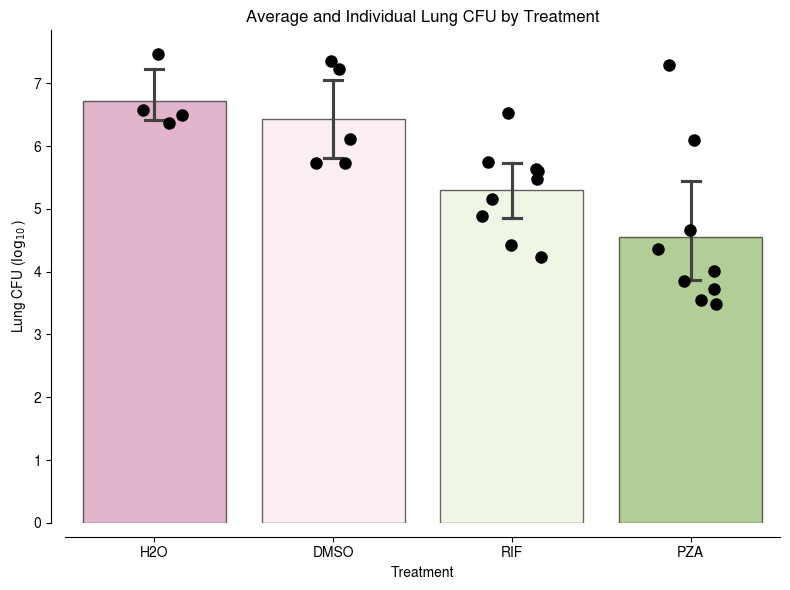

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax = plt.gca()

# 1. Bar Plot for the mean (Average CFU per Treatment)
# The hue is set to 'Treatment' to color the bars, which simplifies the stripplot later.
sns.barplot(
    data=cfu_df,
    x='Treatment',
    y='Lung CFU (log10)',
    ax=ax,
    # errorbar=('ci', 68),  # Shows Mean +/- 1 Standard Error (SEM)
    capsize=0.1,
    alpha=0.6,            # Make the bars slightly transparent
    edgecolor='black',
    linewidth=1,
    palette='PiYG' # Optional: uncomment if you want a specific color palette
)

# 2. Stripplot for individual data points
sns.stripplot(
    data=cfu_df,
    x='Treatment',
    y='Lung CFU (log10)',
    ax=ax,
    color='black',       # Set all points to a single color (black works well over colored bars)
    size=8,
    jitter=0.2,          # Adds horizontal jitter so points don't stack perfectly
    linewidth=1,
    edgecolor='gray', 
    # style='mouse_N'
)

# Remove the default legend, as it usually shows an unnecessary entry for 'stripplot'
if ax.legend_:
    ax.legend().set_visible(False)

sns.despine(offset=10)
# Final Touches
plt.title('Average and Individual Lung CFU by Treatment')
plt.xlabel('Treatment')
plt.ylabel('Lung CFU ($\log_{10}$)')
plt.tight_layout()
plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFU.pdf', bbox_inches='tight', dpi=314)

plt.show()

/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_704808/315191411.py:61: FutureWarning: Use "auto" to set automatic grayscale colors. From 

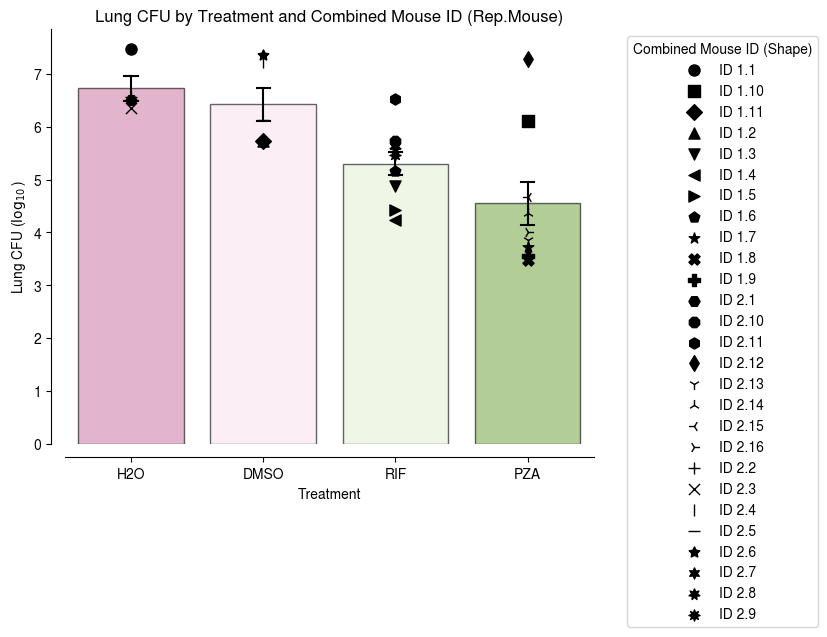

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported if you are creating/modifying the DataFrame

# --- 1. Data Preparation and Mapping ---

# Ensure cfu_df is available in your notebook environment before running this code!

# 1. Ensure rep_N and mouse_N are strings for concatenation
cfu_df['rep_N'] = cfu_df['rep_N'].astype(str)
cfu_df['mouse_N'] = cfu_df['mouse_N'].astype(str)

# 2. CREATE THE NEW COMBINED COLUMN: mouse_ID = rep_N.mouse_N
cfu_df['mouse_ID'] = cfu_df['rep_N'] + '.' + cfu_df['mouse_N']

# 3. Get unique 'mouse_ID' values to build the shape map
mouse_ID_values = sorted(cfu_df['mouse_ID'].unique())
num_unique_ids = len(mouse_ID_values)

# 4. Define markers (must be long enough for all unique IDs, e.g., 11 + 16 = 27 unique IDs)
all_markers = [
    'o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'X', 'P', 'H', '8',
    'h', 'd', '1', '2', '3', '4', '+', 'x', '|', '_',
    (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1) # Adding extra custom markers
]

# 5. Create a dictionary to map 'mouse_ID' value -> marker shape
marker_map = dict(zip(mouse_ID_values, all_markers[:num_unique_ids]))

# --- 2. Setup Plot ---

plt.figure(figsize=(10, 6))
ax = plt.gca()

# 1. Bar Plot for the mean (Average CFU per Treatment)
# Using 'Treatment' for hue to color the bars based on the x-axis groups.
sns.barplot(
    data=cfu_df,
    x='Treatment',
    y='Lung CFU (log10)',
    hue='Treatment',
    ax=ax,
    errorbar=('ci', 68),
    capsize=0.1,
    alpha=0.6,
    err_kws={'color': 'black', 'linewidth': 1.5},
    edgecolor='black',
    linewidth=1,
    palette='PiYG', # Use a distinct color palette
    legend=False # Hide the redundant barplot legend
)

# 2. Scatter Plot for individual data points (Iterating for manual style)
# We iterate over the combined 'mouse_ID' groups to set the 'marker' shape
for mouse_id_val, marker_shape in marker_map.items():
    
    # Filter data for the current mouse_ID
    subset_data = cfu_df[cfu_df['mouse_ID'] == mouse_id_val]
    
    # Plot the subset with the specified marker
    sns.stripplot(
        data=subset_data,
        x='Treatment',
        y='Lung CFU (log10)',
        ax=ax,
        color='black',       # Use a single color (black) for all points for clarity
        size=8,
        jitter=5,
        linewidth=1,
        marker=marker_shape, # <-- KEY MANUAL STEP: uses combined ID for shape
        edgecolor='gray',
        # Add a label for the legend
        label=f'ID {mouse_id_val}'
    )

# --- 3. Legend Cleanup ---

# Finalize and position the legend generated by the stripplots
ax.legend(
    title='Combined Mouse ID (Shape)',
    loc='upper left',
    bbox_to_anchor=(1.05, 1)
)
sns.despine(offset=10)

# Final Touches
plt.title('Lung CFU by Treatment and Combined Mouse ID (Rep.Mouse)')
plt.xlabel('Treatment')
plt.ylabel('Lung CFU ($\log_{10}$)')
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust to fit the legend
plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/CFU_marker_style_separation.pdf', bbox_inches='tight', dpi=314)
plt.show()

### Previous work

In [2]:
df = pd.read_pickle('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/sc_mtb_tissue.pkl')
df

,zarr_address,region_id,mean_intensity_ch1,mean_intensity_ch2,area,bbox_rmin,bbox_rmax,bbox_cmin,bbox_cmax,mouse_N,rep_N,split,condition,timer_ratio,x,y
0,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...,1,669.458333,1154.916667,72.0,12,28,24285,24311,2,1,None,DMSO,0.579659,20,24298
1,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...,2,394.212121,602.606061,33.0,31,46,25260,25278,2,1,None,DMSO,0.654179,38,25269
2,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...,3,613.163636,943.381818,55.0,43,59,25134,25166,2,1,None,DMSO,0.649963,51,25150
3,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...,4,737.836957,1462.576087,92.0,46,69,24763,24787,2,1,None,DMSO,0.504478,57,24775
4,20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAP...,5,257.228070,396.228070,57.0,47,64,27340,27364,2,1,None,DMSO,0.649192,55,27352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452360,rep2_mouse16_top.zarr,501,3168.583333,805.000000,156.0,34194,34228,2815,2845,16,2,top,PZA,3.936128,34211,2830
452361,rep2_mouse16_top.zarr,502,3707.631579,913.567251,171.0,34204,34231,2751,2785,16,2,top,PZA,4.058411,34217,2768
452362,rep2_mouse16_top.zarr,503,4872.142857,1180.142857,7.0,34211,34224,18594,18607,16,2,top,PZA,4.128435,34217,18600
452363,rep2_mouse16_top.zarr,504,3681.236842,837.684211,38.0,34244,34263,765,781,16,2,top,PZA,4.394540,34253,773


In [3]:
# Define the root directory to search in
root_dir = Path('/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/data/whole_slice')
dapi_seg_list=[]
for zarr_address in tqdm(df['zarr_address'].unique()):
    
    # 1. Find the full path to the Zarr file
    # We search specifically for this filename pattern within the root structure
    found_zarrs = list(root_dir.glob(f"rep*/mouse_*/zarr/{zarr_address}"))
    
    if not found_zarrs:
        print(f"⚠️ Zarr file not found on disk: {zarr_address}")
        continue
        
    zarr_path = found_zarrs[0]
    
    # 2. Check for dapi_segmentation inside the Zarr folder
    # Note: In OME-Zarr, 'labels' is a subdirectory
    # We look for any folder/file starting with 'dapi_segmentation' inside 'labels'
    dapi_seg_paths = list(zarr_path.glob("labels/dapi_segmentation*"))
    
    if dapi_seg_paths:
        print(f"✅ Found segmentation: {dapi_seg_paths[0]}")
        dapi_seg_list.append(dapi_seg_paths[0])
    else:
        print(f"❌ MISSING segmentation for: {zarr_address}")

  0%|          | 0/54 [00:00<?, ?it/s]

❌ MISSING segmentation for: 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5551.zarr
❌ MISSING segmentation for: 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5552.zarr
❌ MISSING segmentation for: 20250901_40X_TimerMtb_BP_mice2_mice3_mice4_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250901_5553.zarr
❌ MISSING segmentation for: 20250901_40X_TimerMtb_BP_mice5_mice6_mice7_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250903_5555.zarr
❌ MISSING segmentation for: 20250815_40X_TimerMtb_BP_mice1_DAPI_TimerG_TimerR_Multichannel Z-Stack_20250815_5375.zarr
✅ Found segmentation: /mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/data/whole_slice/rep2/mouse_1/zarr/20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice1_DAPI_TimerG_TimerR_Multichannel Z-Stack_20251002_5574.zarr/labels/dapi_segmentation
✅ Found segmentation: /mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/data/whole_slice/rep2/mouse_2/zarr/20

In [4]:
seg_path = dapi_seg_list[0]

In [5]:
# -- B. Load the Zarr Array --
try:
    # Open the Zarr array (read-only mode is safer)
    # We access the '0' scale level (highest resolution) by default in OME-Zarr
    # Adjust ['0'] if your segmentation isn't multiscaled
    z_grp = zarr.open(str(seg_path), mode='r')
    
    # OME-Zarr often stores data in a numbered subgroup like '0', '1', '2' (pyramid levels)
    # We try to grab the high-res level '0'
    if '0' in z_grp:
        dapi_mask = z_grp['0']#[:]
    else:
        # If it's a flat array (not OME-Zarr pyramid), just read it directly
        dapi_mask = z_grp#[:]
        
    # Squeeze to remove extra dimensions (e.g., T or C if they exist and are size 1)
    # e.g., (1, 1, Y, X) -> (Y, X)
    # dapi_mask = np.squeeze(dapi_mask)
    
except Exception as e:
    print(f"Error reading {seg_path}: {e}")
    # continue


Error reading /mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/data/whole_slice/rep2/mouse_1/zarr/20251001_40X_TimerMtb_BP_rep2_mice3_mice2_mice1_DAPI_TimerG_TimerR_Multichannel Z-Stack_20251002_5574.zarr/labels/dapi_segmentation: name 'zarr' is not defined


In [ ]:
import gc
import re

import numpy as np
import pandas as pd
import zarr
from skimage.measure import regionprops_table
from tqdm import tqdm

# --- 1. Prepare Metadata Lookup ---
if 'condition' in df.columns:
    meta_lookup = df[['rep_N', 'mouse_N', 'condition']].drop_duplicates().set_index(['rep_N', 'mouse_N'])['condition'].to_dict()
else:
    print("⚠️ Warning: 'condition' column missing from df. Conditions will be NaN.")
    meta_lookup = {}

# Define output directory for the individual pickles
output_dir = '/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/dapi_pickles/'
os.makedirs(output_dir, exist_ok=True)

# --- 2. Iterate and Process (RAM SAFE) ---
print(f"Extracting nuclei coordinates from {len(dapi_seg_list)} images...")

for seg_path in tqdm(dapi_seg_list):
    
    # -- A. Extract Metadata from Path --
    match = re.search(r'/rep(\d+)/mouse_?(\d+)/', str(seg_path))
    
    if match:
        rep = int(match.group(1))
        mouse = int(match.group(2))
        condition = meta_lookup.get((rep, mouse), "Unknown")
    else:
        continue

    # -- B. Load the Zarr Array --
    try:
        z_grp = zarr.open(str(seg_path), mode='r')
        if '0' in z_grp:
            dapi_mask = z_grp['0'][:]
        else:
            dapi_mask = z_grp[:]
        
        dapi_mask = np.squeeze(dapi_mask)
        
    except Exception as e:
        print(f"Error reading {seg_path}: {e}")
        continue

    # -- C. Extract Centroids --
    try:
        props = regionprops_table(dapi_mask, properties=('label', 'centroid'))
        
        # Create a temporary DataFrame
        temp_df = pd.DataFrame(props)
        
        # Free up the mask memory immediately
        del dapi_mask
        
        if 'centroid-0' in temp_df.columns and 'centroid-1' in temp_df.columns:
            temp_df = temp_df.rename(columns={'centroid-0': 'y', 'centroid-1': 'x'})
            
            # Add metadata columns
            temp_df['rep_N'] = rep
            temp_df['mouse_N'] = mouse
            temp_df['condition'] = condition
            
            # Extract Zarr Filename for unique saving
            parent_zarr = pd.Series(str(seg_path)).str.extract(r'([^/]+\.zarr)')[0][0]
            temp_df['zarr_address'] = parent_zarr
            
            # -- SAVE IMMEDIATELY --
            # Use zarr name to ensure uniqueness (avoids overwrites)
            save_path = os.path.join(output_dir, f"{parent_zarr}_nuclei.pkl")
            temp_df.to_pickle(save_path)
            
            # -- CLEANUP --
            del temp_df
            del props
            gc.collect() # Force Python to release memory
            
    except ValueError:
        continue
    except Exception as e:
        print(f"Error processing {seg_path}: {e}")
        continue

print("Done! All files saved individually.")

Extracting nuclei coordinates from 16 images...


  0%|                                                                                           | 0/16 [00:00<?, ?it/s]

In [ ]:
yabbadabbado

In [ ]:
import os
import re

import numpy as np
import pandas as pd
import zarr

# from tqdm import tqdm
from skimage.measure import regionprops_table

# --- 1. Prepare Metadata Lookup ---
# Create a dictionary to quickly find 'condition' based on (rep, mouse)
# This prevents us from having to do slow merges later.
# Format: { (1, 2): 'H2O', (1, 3): 'DMSO', ... }
if 'condition' in df.columns:
    meta_lookup = df[['rep_N', 'mouse_N', 'condition']].drop_duplicates().set_index(['rep_N', 'mouse_N'])['condition'].to_dict()
else:
    print("⚠️ Warning: 'condition' column missing from df. Conditions will be NaN.")
    meta_lookup = {}

nuclei_data_list = []

# --- 2. Iterate and Process ---
print(f"Extracting nuclei coordinates from {len(dapi_seg_list)} images...")

for seg_path in tqdm(dapi_seg_list):
    
    # -- A. Extract Metadata from Path --
    # We use the full path string to find Rep and Mouse numbers
    # Regex looks for /repX/ and /mouse_Y/
    match = re.search(r'/rep(\d+)/mouse_?(\d+)/', str(seg_path))
    
    if match:
        rep = int(match.group(1))
        mouse = int(match.group(2))
        condition = meta_lookup.get((rep, mouse), "Unknown")
    else:
        print(f"Skipping (Metadata not found in path): {seg_path}")
        continue

    # -- B. Load the Zarr Array --
    try:
        # Open the Zarr array (read-only mode is safer)
        # We access the '0' scale level (highest resolution) by default in OME-Zarr
        # Adjust ['0'] if your segmentation isn't multiscaled
        z_grp = zarr.open(str(seg_path), mode='r')
        
        # OME-Zarr often stores data in a numbered subgroup like '0', '1', '2' (pyramid levels)
        # We try to grab the high-res level '0'
        if '0' in z_grp:
            dapi_mask = z_grp['0'][:]
        else:
            # If it's a flat array (not OME-Zarr pyramid), just read it directly
            dapi_mask = z_grp[:]
            
        # Squeeze to remove extra dimensions (e.g., T or C if they exist and are size 1)
        # e.g., (1, 1, Y, X) -> (Y, X)
        dapi_mask = np.squeeze(dapi_mask)
        
    except Exception as e:
        print(f"Error reading {seg_path}: {e}")
        continue

    # -- C. Extract Centroids --
    # regionprops_table is much faster than looping through regions
    try:
        props = regionprops_table(dapi_mask, properties=('label', 'centroid'))
        
        # Create a temporary DataFrame
        temp_df = pd.DataFrame(props)
        
        # Rename columns standard names (centroid-0 is Y, centroid-1 is X)
        # Note: If 3D, you might get centroid-0 (Z), -1 (Y), -2 (X). Check shape!
        if 'centroid-0' in temp_df.columns and 'centroid-1' in temp_df.columns:
            temp_df = temp_df.rename(columns={'centroid-0': 'y', 'centroid-1': 'x'})
            
            # Add metadata columns
            temp_df['rep_N'] = rep
            temp_df['mouse_N'] = mouse
            temp_df['condition'] = condition
            
            # Store the basename of the Zarr for reference
            # Assuming seg_path is .../filename.zarr/labels/dapi_segmentation
            # We go up 3 levels to find the .zarr folder name
            parent_zarr = pd.Series(str(seg_path)).str.extract(r'([^/]+\.zarr)')[0][0]
            temp_df['zarr_address'] = parent_zarr
            
            nuclei_data_list.append(temp_df)
        temp_df.to_pickle(f'/mnt/OPERA3/Nathan/data/macrohet/mtb_tissue_localisation/results/dapi_coords_rep{rep}_mouse{mouse}.pkl')
    except ValueError:
        # Happens if mask is empty
        continue

# --- 3. Combine into Final DataFrame ---
if nuclei_data_list:
    nuclei_df = pd.concat(nuclei_data_list, ignore_index=True)
    print("Done!")
    print(nuclei_df.head())
else:
    print("No nuclei data extracted.")

# 

# 

# 

# 

# 